# Phase 0 — Physics Layer Inspection

Validates and visualises every building block implemented in Phase 0:
courses (synthetic + GPX), force physics, four W' models, the 4-parameter
power-duration curve, and the ForwardSimulator — explored across four rider archetypes.

**Sections**
- §0 Setup & archetypes
- §1 Course inspection
- §2 Force components & power breakdown
- §3 Wind analysis
- §4 Power-duration model & W' model comparison
- §5 W' as a function of the course
- §6 Rider archetype simulations
- §7 Launch phase
- §8 Simulation diagnostics

---
## §0 — Setup & archetype definitions

In [1]:
import sys
sys.path.insert(0, "../src")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

from ttt_strat.course import CourseData, CourseProcessor, load_gpx
from ttt_strat.wind import WindField
from ttt_strat.rider import Rider
from ttt_strat.physics import rolling_force_N, aero_force_N, grav_force_N, G_M_PER_S2
from ttt_strat.simulator import ForwardSimulator
from ttt_strat.w_prime.linear import LinearModel
from ttt_strat.w_prime.skiba import SkibaModel
from ttt_strat.w_prime.bartram import BartramModel
from ttt_strat.w_prime.differential import DifferentialModel
from ttt_strat.w_prime.caen import CaenModel

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SIM = ForwardSimulator()

In [2]:
# ── Rider archetypes ─────────────────────────────────────────────────────────
# mass [kg]: combined rider + bike
# cp [W]: critical power
# w_prime [J]: anaerobic work capacity W'
# p_max [W]: maximal instantaneous sprint power
# tau [s]: PD-curve crossover time constant (governs Pmax→CP+W'/t transition)
# cda [m²]: drag area; crr [dimensionless]: rolling-resistance coefficient
ARCHETYPES: dict[str, dict] = {
    "Pure climber":     {"mass": 60.0, "cp": 360.0, "w_prime": 15_000.0, "p_max": 950.0,  "tau": 25.0, "cda": 0.30, "crr": 4e-3},
    "Sprinter":         {"mass": 80.0, "cp": 380.0, "w_prime": 30_000.0, "p_max": 1700.0, "tau": 35.0, "cda": 0.34, "crr": 4e-3},
    "Classics puncher": {"mass": 70.0, "cp": 400.0, "w_prime": 22_000.0, "p_max": 1300.0, "tau": 30.0, "cda": 0.32, "crr": 4e-3},
    "TT specialist":    {"mass": 73.0, "cp": 410.0, "w_prime": 18_000.0, "p_max": 1050.0, "tau": 28.0, "cda": 0.25, "crr": 4e-3},
}

L_DRIVE       = 0.02    # drivetrain loss fraction [dimensionless]
F_MAX_N       = 1500.0  # launch traction limit [N]
RHO_KG_PER_M3 = 1.225   # air density [kg/m³]
V_MATCH_M_PER_S = 2.0   # launch hand-off speed [m/s]

ARCHETYPE_NAMES = list(ARCHETYPES.keys())
ARCH_COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

W_PRIME_MODELS = {
    "Linear":       LinearModel(),
    "Skiba":        SkibaModel(),
    "Bartram":      BartramModel(),
    "Differential": DifferentialModel(),
    "Caen":         CaenModel(),
}
MODEL_COLORS   = {"Linear": "#9b59b6", "Skiba": "#e74c3c", "Bartram": "#3498db", "Differential": "#2ecc71", "Caen": "#e67e22"}
MODEL_STYLES   = {"Linear": "--",      "Skiba": "-.",      "Bartram": ":",        "Differential": "-",       "Caen": (0, (3, 1, 1, 1))}
CAEN_EXACT_COLOR = "#d35400"
CAEN_EXACT_STYLE = (0, (5, 2, 1, 2))

CALM_WIND = WindField(w_east_m_per_s=0.1, w_north_m_per_s=0.1)


def make_rider(a: dict, model=None) -> Rider:
    return Rider(
        mass_kg=a["mass"],
        cp_W=a["cp"],
        w_prime_J=a["w_prime"],
        cda_m2=a["cda"],
        crr=a["crr"],
        l_drivetrain=L_DRIVE,
        w_prime_model=model if model is not None else DifferentialModel(),
        f_max_N=F_MAX_N,
    )


RIDERS = {name: make_rider(a) for name, a in ARCHETYPES.items()}

In [3]:
rows = []
for name, a in ARCHETYPES.items():
    rows.append({
        "Archetype":       name,
        "Mass [kg]": a["mass"],
        "CP [W]": a["cp"],
        "CP/kg [W/kg]": round(a["cp"] / a["mass"], 2),
        "W' [kJ]": a["w_prime"] / 1000,
        "W'/kg [J/kg]": round(a["w_prime"] / a["mass"], 1),
        "Pmax [W]": a["p_max"],
        "τ [s]": a["tau"],
        "CdA [m²]": a["cda"],
    })
df_archetypes = pd.DataFrame(rows).set_index("Archetype")
df_archetypes

,Mass [kg],CP [W],CP/kg [W/kg],W' [kJ],W'/kg [J/kg],Pmax [W],τ [s],CdA [m²]
Archetype,,,,,,,,
Pure climber,60.0,360.0,6.00,15.0,250.0,950.0,25.0,0.30
Sprinter,80.0,380.0,4.75,30.0,375.0,1700.0,35.0,0.34
Classics puncher,70.0,400.0,5.71,22.0,314.3,1300.0,30.0,0.32
TT specialist,73.0,410.0,5.62,18.0,246.6,1050.0,28.0,0.25


In [4]:
# ── Synthetic flat course (40 km, 400 nodes) ─────────────────────────────────
N_FLAT = 400
flat_raw = CourseData(
    s_m=np.linspace(0, 40_000, N_FLAT),
    grade=np.full(N_FLAT, 1e-3),
    bearing_rad=np.full(N_FLAT, 1e-4),
    surface_factor=np.ones(N_FLAT),
)
flat_course = CourseProcessor().process(flat_raw, N_FLAT, smoothing_length_m=200.0)

# ── Real GPX course — Tour Auvergne-Rhône-Alpes Stage 3 ──────────────────────
gpx_raw  = load_gpx("../data/ttt_strat/input/tara2026_stage3.gpx")
gpx_course = CourseProcessor().process(gpx_raw, 600, smoothing_length_m=200.0)

print(f"Flat   : {flat_course.s_m[-1]/1000:.1f} km, {len(flat_course.s_m)} nodes")
print(f"GPX    : {gpx_course.s_m[-1]/1000:.1f} km, {len(gpx_course.s_m)} nodes")
print(f"GPX grade: {np.degrees(np.arctan(np.tan(gpx_course.theta_rad))).min():.1f}% to "
      f"{np.degrees(np.arctan(np.tan(gpx_course.theta_rad))).max():.1f}%")

Flat   : 40.0 km, 400 nodes
GPX    : 28.4 km, 600 nodes
GPX grade: -6.3% to 9.9%


---
## §1 — Course inspection

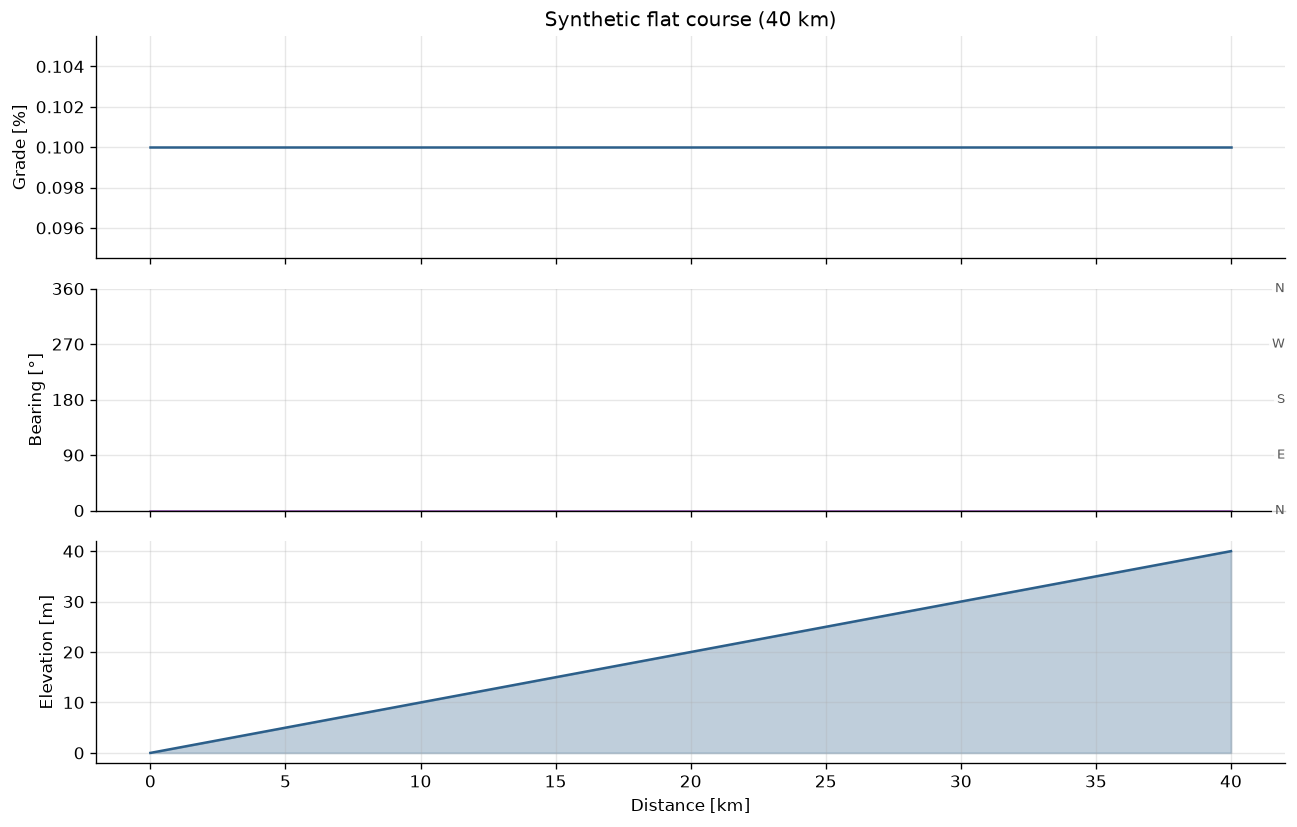

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
km_flat = flat_course.s_m / 1000
grade_pct_flat = np.tan(flat_course.theta_rad) * 100
elev_flat = np.cumsum(np.concatenate([[0], np.diff(flat_course.s_m) * np.tan(flat_course.theta_rad[:-1])]))

axes[0].plot(km_flat, grade_pct_flat, color="#2c5f8a")
axes[0].set_ylabel("Grade [%]")
axes[0].set_title("Synthetic flat course (40 km)")

axes[1].plot(km_flat, np.degrees(flat_course.bearing_rad), color="#8e44ad")
axes[1].set_ylabel("Bearing [°]")
axes[1].set_ylim(0, 360)
axes[1].set_yticks([0, 90, 180, 270, 360])
for deg, card in [(0, "N"), (90, "E"), (180, "S"), (270, "W"), (360, "N")]:
    axes[1].text(1.0, deg, card, transform=axes[1].get_yaxis_transform(),
                 ha="right", va="center", fontsize=8, color="#555", clip_on=False,
                 bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2))

axes[2].fill_between(km_flat, elev_flat, alpha=0.3, color="#2c5f8a")
axes[2].plot(km_flat, elev_flat, color="#2c5f8a")
axes[2].set_ylabel("Elevation [m]")
axes[2].set_xlabel("Distance [km]")

plt.tight_layout()
plt.show()

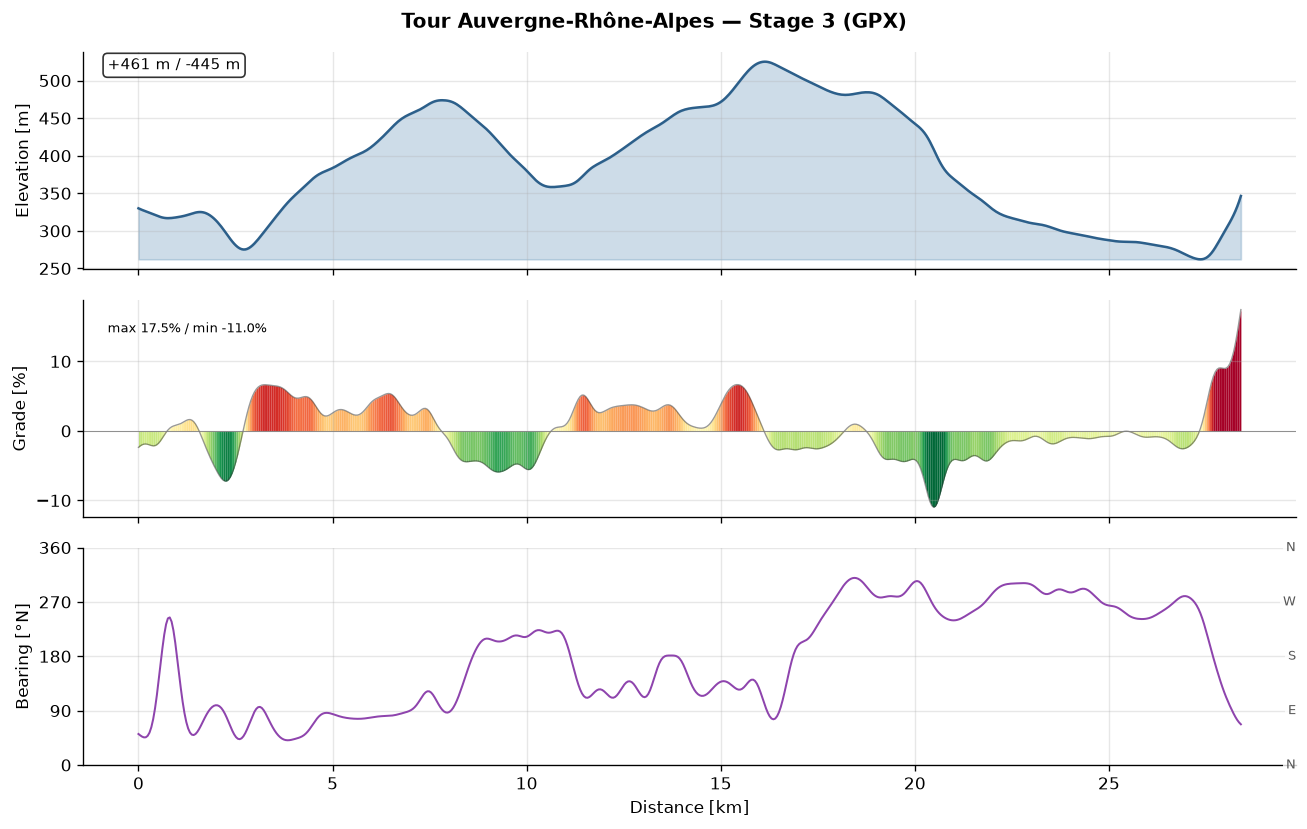

In [6]:
km_gpx   = gpx_course.s_m / 1000
grade_gpx = np.tan(gpx_course.theta_rad) * 100

# Reconstruct elevation from grade
elev_gpx = np.concatenate([[gpx_raw.s_m[0] * 0],  # placeholder origin
    np.cumsum(np.diff(gpx_course.s_m) * np.tan(gpx_course.theta_rad[:-1]))])
raw_elev_start_m = gpx_raw.elev_start_m
elev_gpx = elev_gpx - elev_gpx[0] + raw_elev_start_m

total_ascent  = np.sum(np.diff(elev_gpx)[np.diff(elev_gpx) > 0])
total_descent = np.sum(np.diff(elev_gpx)[np.diff(elev_gpx) < 0])

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
fig.suptitle("Tour Auvergne-Rhône-Alpes — Stage 3 (GPX)", fontsize=12, fontweight="bold")

axes[0].fill_between(km_gpx, elev_gpx, elev_gpx.min(), alpha=0.3, color="#5b8eb5")
axes[0].plot(km_gpx, elev_gpx, color="#2c5f8a", lw=1.5)
axes[0].set_ylabel("Elevation [m]")
axes[0].annotate(f"+{total_ascent:.0f} m / {total_descent:.0f} m",
                 xy=(0.02, 0.92), xycoords="axes fraction", fontsize=9,
                 bbox=dict(boxstyle="round", fc="white", alpha=0.8))

cmap_grade = plt.get_cmap("RdYlGn_r")
norm_grade = plt.Normalize(vmin=-8, vmax=8)
for i in range(len(km_gpx) - 1):
    axes[1].fill_between(km_gpx[i:i+2], grade_gpx[i:i+2], color=cmap_grade(norm_grade(grade_gpx[i])), lw=0)
axes[1].plot(km_gpx, grade_gpx, color="#333", lw=0.8, alpha=0.5)
axes[1].set_ylabel("Grade [%]")
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].annotate(f"max {grade_gpx.max():.1f}% / min {grade_gpx.min():.1f}%",
                 xy=(0.02, 0.85), xycoords="axes fraction", fontsize=8)

axes[2].plot(km_gpx, np.degrees(gpx_course.bearing_rad), color="#8e44ad", lw=1.2)
axes[2].set_ylabel("Bearing [°N]")
axes[2].set_ylim(0, 360)
axes[2].set_yticks([0, 90, 180, 270, 360])
axes[2].set_xlabel("Distance [km]")
for deg, card in [(0, "N"), (90, "E"), (180, "S"), (270, "W"), (360, "N")]:
    axes[2].text(1.0, deg, card, transform=axes[2].get_yaxis_transform(),
                 ha="right", va="center", fontsize=8, color="#555", clip_on=False,
                 bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2))

plt.tight_layout()
plt.show()

In [7]:
def course_stats(course, label, raw_elev_offset_m=0.0):
    g = np.tan(course.theta_rad) * 100
    e = np.cumsum(np.concatenate([[raw_elev_offset_m],
        np.diff(course.s_m) * np.tan(course.theta_rad[:-1])]))
    asc  = np.sum(np.diff(e)[np.diff(e) > 0])
    desc = abs(np.sum(np.diff(e)[np.diff(e) < 0]))
    return {
        "Course": label,
        "Length [km]": round(course.s_m[-1] / 1000, 1),
        "Nodes": len(course.s_m),
        "Max grade [%]": round(g.max(), 2),
        "Min grade [%]": round(g.min(), 2),
        "Total ascent [m]": round(asc, 0),
        "Total descent [m]": round(desc, 0),
        "Elev range [m]": round(e.max() - e.min(), 0),
    }

pd.DataFrame([
    course_stats(flat_course, "Synthetic flat"),
    course_stats(gpx_course,  "TARA 2026 Stage 3 GPX", raw_elev_offset_m=raw_elev_start_m),
]).set_index("Course")

,Length [km],Nodes,Max grade [%],Min grade [%],Total ascent [m],Total descent [m],Elev range [m]
Course,,,,,,,
Synthetic flat,40.0,400,0.10,0.10,40.0,0.0,40.0
TARA 2026 Stage 3 GPX,28.4,600,17.45,-10.98,461.0,445.0,263.0


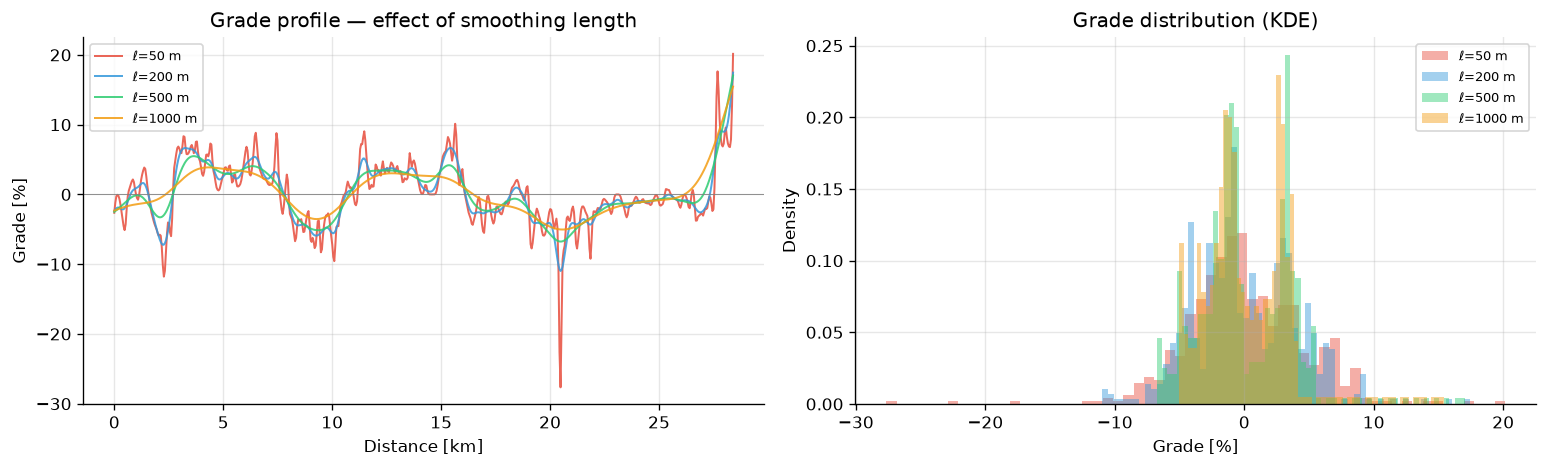

In [8]:
smoothing_lengths = [50, 200, 500, 1000]
fig, (ax_g, ax_h) = plt.subplots(1, 2, figsize=(13, 4))
colors_sm = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

for ell, col in zip(smoothing_lengths, colors_sm):
    c = CourseProcessor().process(gpx_raw, 600, smoothing_length_m=float(ell))
    g = np.tan(c.theta_rad) * 100
    ax_g.plot(c.s_m / 1000, g, color=col, lw=1.2, alpha=0.85, label=f"ℓ={ell} m")
    ax_h.hist(g, bins=60, color=col, alpha=0.45, density=True, label=f"ℓ={ell} m")

ax_g.set_xlabel("Distance [km]")
ax_g.set_ylabel("Grade [%]")
ax_g.set_title("Grade profile — effect of smoothing length")
ax_g.legend(fontsize=8)
ax_g.axhline(0, color="gray", lw=0.5)

ax_h.set_xlabel("Grade [%]")
ax_h.set_ylabel("Density")
ax_h.set_title("Grade distribution (KDE)")
ax_h.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## §2 — Force components and power breakdown

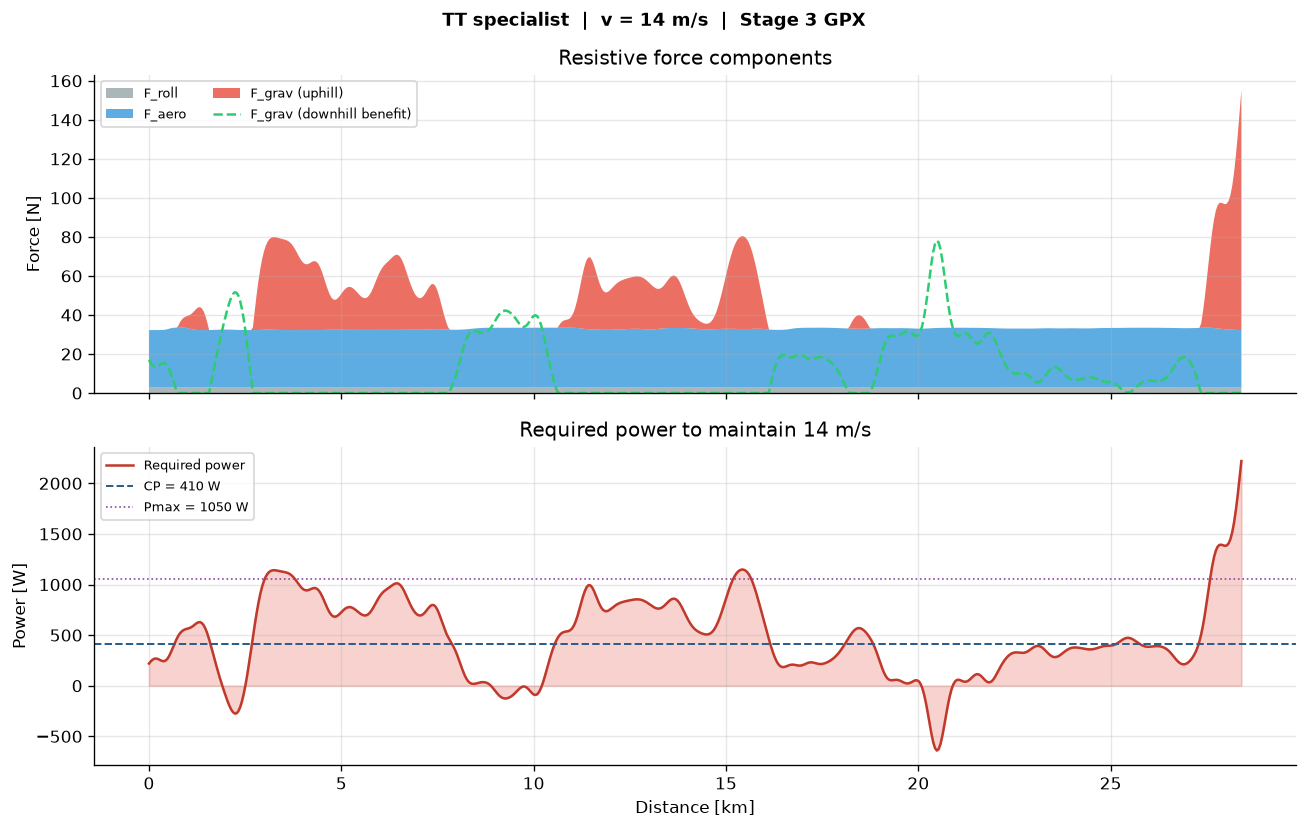

In [9]:
# TT specialist at constant v = 14 m/s (~50 km/h), no wind, along Stage 3
a_tt = ARCHETYPES["TT specialist"]
v_const = 14.0  # m/s
v_w_arr = CALM_WIND.head_wind_m_per_s(gpx_course.bearing_rad)

F_rr = np.array([rolling_force_N(a_tt["crr"], a_tt["mass"], th) for th in gpx_course.theta_rad])
F_ae = np.array([aero_force_N(RHO_KG_PER_M3, a_tt["cda"], v_const, vw) for vw in v_w_arr])
F_gr = np.array([grav_force_N(a_tt["mass"], th) for th in gpx_course.theta_rad])
P_req = (F_rr + F_ae + F_gr) * v_const / (1 - L_DRIVE)

fig, (ax_f, ax_p) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
fig.suptitle("TT specialist  |  v = 14 m/s  |  Stage 3 GPX", fontsize=11, fontweight="bold")

ax_f.stackplot(km_gpx, F_rr, F_ae, np.clip(F_gr, 0, None),
               labels=["F_roll", "F_aero", "F_grav (uphill)"],
               colors=["#95a5a6", "#3498db", "#e74c3c"], alpha=0.8)
ax_f.plot(km_gpx, -np.clip(F_gr, None, 0), color="#2ecc71", lw=1.5, label="F_grav (downhill benefit)", ls="--")
ax_f.set_ylabel("Force [N]")
ax_f.legend(fontsize=8, ncol=2)
ax_f.set_title("Resistive force components")

ax_p.fill_between(km_gpx, P_req, alpha=0.25, color="#e74c3c")
ax_p.plot(km_gpx, P_req, color="#c0392b", lw=1.5, label="Required power")
ax_p.axhline(a_tt["cp"], color="#2c5f8a", lw=1.2, ls="--", label=f"CP = {a_tt['cp']:.0f} W")
ax_p.axhline(a_tt["p_max"], color="#8e44ad", lw=1, ls=":", label=f"Pmax = {a_tt['p_max']:.0f} W")
ax_p.set_ylabel("Power [W]")
ax_p.set_xlabel("Distance [km]")
ax_p.legend(fontsize=8)
ax_p.set_title("Required power to maintain 14 m/s")

plt.tight_layout()
plt.show()

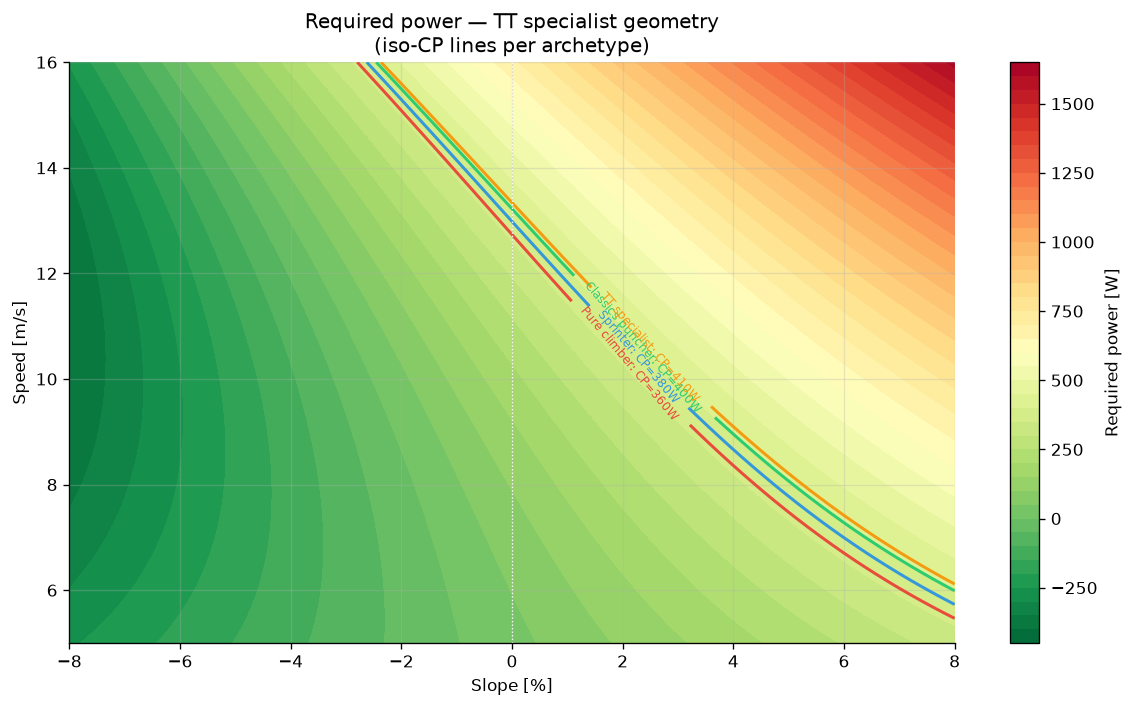

In [10]:
slopes_pct = np.linspace(-8, 8, 80)
speeds_ms  = np.linspace(5, 16, 60)
SL, SP = np.meshgrid(slopes_pct, speeds_ms)
THETA = np.arctan(SL / 100)

P_grid = np.zeros_like(SL)
for i, v in enumerate(speeds_ms):
    for j, sl in enumerate(slopes_pct):
        th = math.atan(sl / 100)
        F = (rolling_force_N(a_tt["crr"], a_tt["mass"], th)
             + aero_force_N(RHO_KG_PER_M3, a_tt["cda"], v, 0.0)
             + grav_force_N(a_tt["mass"], th))
        P_grid[i, j] = F * v / (1 - L_DRIVE)

fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(SL, SP, P_grid, levels=40, cmap="RdYlGn_r")
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label("Required power [W]")

for name, col in zip(ARCHETYPE_NAMES, ARCH_COLORS):
    cp = ARCHETYPES[name]["cp"]
    cs = ax.contour(SL, SP, P_grid, levels=[cp], colors=[col], linewidths=1.8, linestyles="-")
    ax.clabel(cs, fmt=f"{name}: CP={cp:.0f}W", fontsize=7, inline=True)

ax.set_xlabel("Slope [%]")
ax.set_ylabel("Speed [m/s]")
ax.set_title("Required power — TT specialist geometry\n(iso-CP lines per archetype)")
ax.axvline(0, color="white", lw=0.8, ls=":")
plt.tight_layout()
plt.show()

---
## §3 — Wind analysis

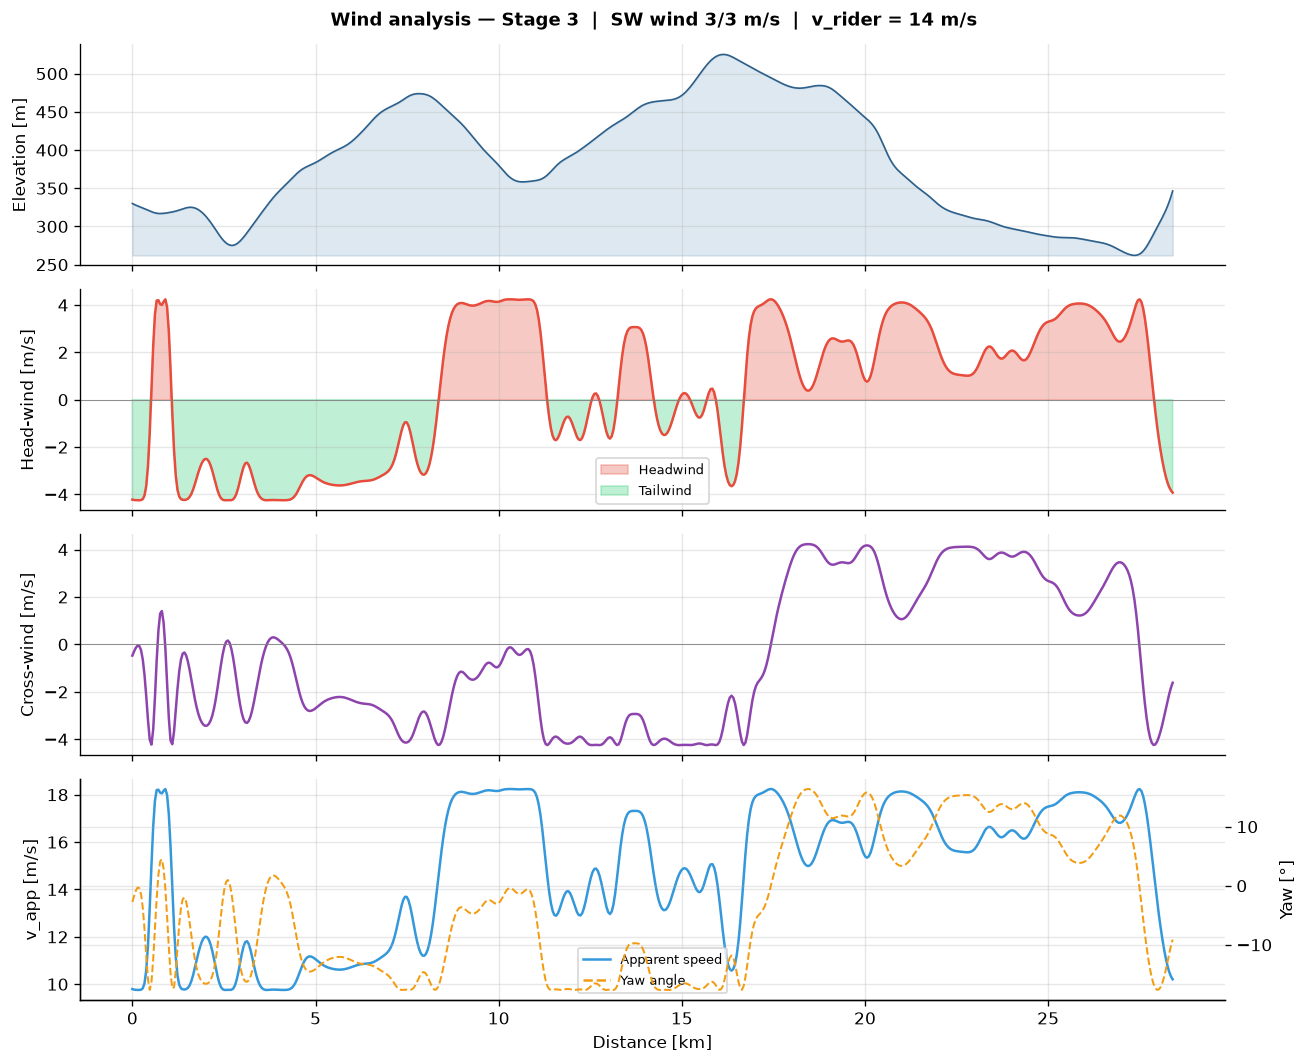

In [11]:
# SW wind: w_east = 3, w_north = 3 m/s  →  |w| ≈ 4.2 m/s from SW
sw_wind = WindField(w_east_m_per_s=3.0, w_north_m_per_s=3.0)

v_head  = sw_wind.head_wind_m_per_s(gpx_course.bearing_rad)
v_cross = sw_wind.cross_wind_m_per_s(gpx_course.bearing_rad)

v_ref = 14.0
v_app  = sw_wind.apparent_speed_m_per_s(v_ref, gpx_course.bearing_rad)
yaw_deg = np.degrees(sw_wind.yaw_rad(v_ref, gpx_course.bearing_rad))

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
fig.suptitle("Wind analysis — Stage 3  |  SW wind 3/3 m/s  |  v_rider = 14 m/s", fontsize=11, fontweight="bold")

axes[0].fill_between(km_gpx, elev_gpx, elev_gpx.min(), alpha=0.2, color="#5b8eb5")
axes[0].plot(km_gpx, elev_gpx, color="#2c5f8a", lw=1)
axes[0].set_ylabel("Elevation [m]")

axes[1].plot(km_gpx, v_head, color="#e74c3c", lw=1.5)
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].fill_between(km_gpx, v_head, where=v_head > 0, alpha=0.3, color="#e74c3c", label="Headwind")
axes[1].fill_between(km_gpx, v_head, where=v_head < 0, alpha=0.3, color="#2ecc71", label="Tailwind")
axes[1].set_ylabel("Head-wind [m/s]")
axes[1].legend(fontsize=8)

axes[2].plot(km_gpx, v_cross, color="#8e44ad", lw=1.5)
axes[2].axhline(0, color="gray", lw=0.5)
axes[2].set_ylabel("Cross-wind [m/s]")

axes[3].plot(km_gpx, v_app,  color="#3498db", lw=1.5, label="Apparent speed")
ax_yaw = axes[3].twinx()
ax_yaw.plot(km_gpx, yaw_deg, color="#f39c12", lw=1.2, ls="--", label="Yaw [°]")
axes[3].set_ylabel("v_app [m/s]")
ax_yaw.set_ylabel("Yaw [°]")
axes[3].set_xlabel("Distance [km]")
h1 = Line2D([0], [0], color="#3498db", label="Apparent speed")
h2 = Line2D([0], [0], color="#f39c12", ls="--", label="Yaw angle")
axes[3].legend(handles=[h1, h2], fontsize=8)

plt.tight_layout()
plt.show()

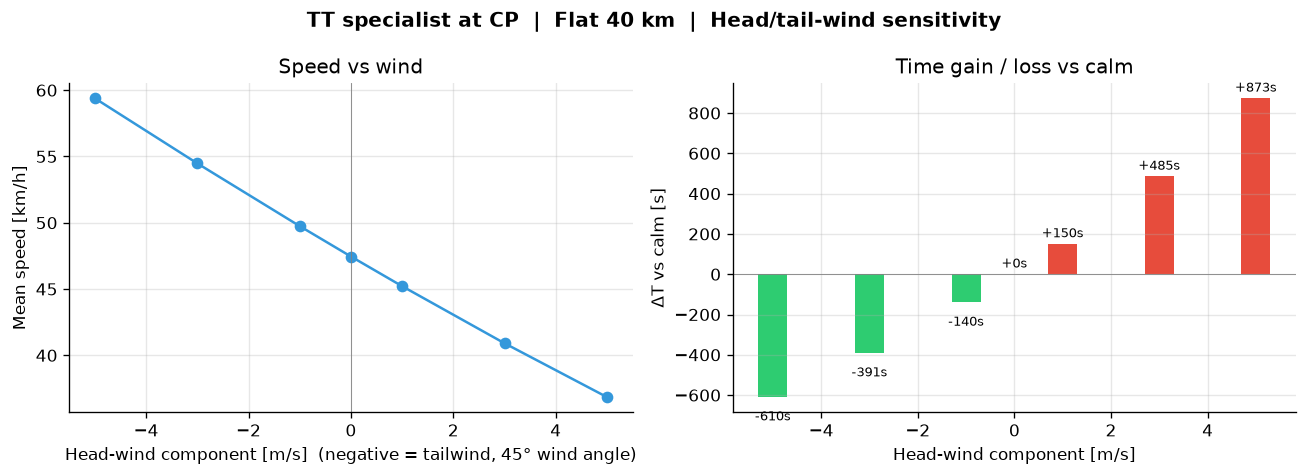

In [12]:
# TT specialist at CP on flat course, varying headwind
headwinds = [-5, -3, -1, 0, 1, 3, 5]  # m/s; negative = tailwind
tt_rider = RIDERS["TT specialist"]
cp_tt = ARCHETYPES["TT specialist"]["cp"]

mean_speeds, delta_times = [], []
ref_time = None

for hw in headwinds:
    wind = WindField(w_east_m_per_s=float(hw), w_north_m_per_s=-float(hw))
    res = SIM.simulate(tt_rider, flat_course, wind, np.full(N_FLAT, cp_tt))
    mean_speeds.append(flat_course.s_m[-1] / res.time_total_s * 3.6)  # km/h
    if hw == 0:
        ref_time = res.time_total_s
    delta_times.append(res.time_total_s)

delta_times = np.array(delta_times) - ref_time

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("TT specialist at CP  |  Flat 40 km  |  Head/tail-wind sensitivity", fontweight="bold")

ax1.plot(headwinds, mean_speeds, "o-", color="#3498db")
ax1.axvline(0, color="gray", lw=0.5)
ax1.set_xlabel("Head-wind component [m/s]  (negative = tailwind, 45° wind angle)")
ax1.set_ylabel("Mean speed [km/h]")
ax1.set_title("Speed vs wind")

bars = ax2.bar(headwinds, delta_times, color=["#2ecc71" if dt < 0 else "#e74c3c" for dt in delta_times], width=0.6)
ax2.axhline(0, color="gray", lw=0.5)
ax2.set_xlabel("Head-wind component [m/s]")
ax2.set_ylabel("ΔT vs calm [s]")
ax2.set_title("Time gain / loss vs calm")
for bar, dt in zip(bars, delta_times):
    ax2.annotate(f"{dt:+.0f}s", xy=(bar.get_x() + bar.get_width()/2, dt),
                 xytext=(0, 4 if dt >= 0 else -14), textcoords="offset points",
                 ha="center", fontsize=8)

plt.tight_layout()
plt.show()

---
## §4 — Power-duration model & W' model comparison

### 4-parameter power-duration model

The standard 2-parameter CP model diverges as $t \to 0$:
$$P_\mathrm{2P}(t) = \mathrm{CP} + \frac{W'}{t}$$

The 4-parameter mixed-exponential model regularises this using $\tau$ and $P_\mathrm{max}$:

$$\boxed{P(t) = \mathrm{CP} + \frac{W'}{t}\bigl(1 - e^{-t/\tau}\bigr) + (P_\mathrm{max} - \mathrm{CP})\,e^{-t/\tau}}$$

| Symbol | Meaning | Unit |
|---|---|---|
| $\mathrm{CP}$ | Critical power (sustainable aerobic power asymptote) | W |
| $W'$ | Anaerobic work capacity | J |
| $P_\mathrm{max}$ | Maximal instantaneous sprint power | W |
| $\tau$ | Crossover time constant (governs decay from $P_\mathrm{max}$ toward $\mathrm{CP}+W'/t$) | s |

**Limits:**
- $t \to 0$: $W'/t$ term $\to W'/\tau$ (finite), sprint term $\to P_\mathrm{max} - \mathrm{CP}$  
  → $P \approx P_\mathrm{max} + W'/\tau$ (slight overshoot at very short durations)
- $t \to \infty$: $P \to \mathrm{CP} + W'/t$ (standard 2-parameter regime)
- $t = \tau$: midpoint crossover between sprint-dominated and $W'$-dominated regimes

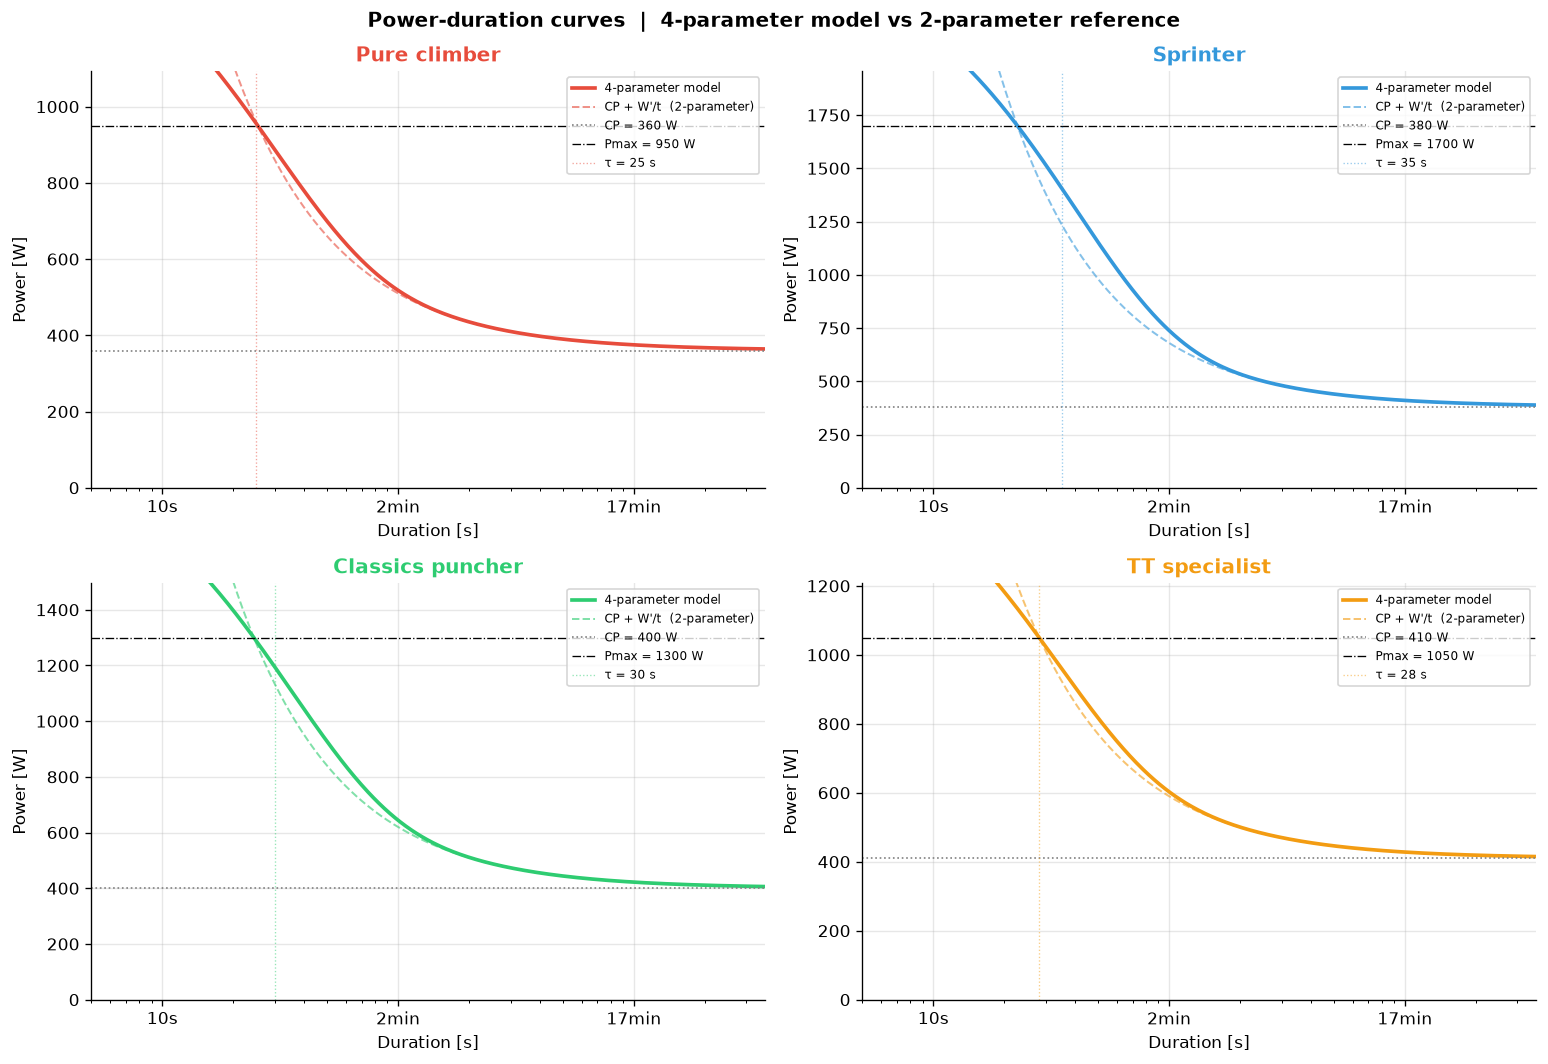

In [13]:
def pd_4param(t, cp, w_prime, p_max, tau):
    """4-parameter power-duration model [W]."""
    return cp + (w_prime / t) * (1 - np.exp(-t / tau)) + (p_max - cp) * np.exp(-t / tau)

def pd_2param(t, cp, w_prime):
    """2-parameter power-duration model [W]."""
    return cp + w_prime / t

t_arr = np.logspace(np.log10(5), np.log10(3600), 500)  # 5 s … 1 h

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
fig.suptitle("Power-duration curves  |  4-parameter model vs 2-parameter reference",
             fontsize=12, fontweight="bold")

for ax, (name, col) in zip(axes, zip(ARCHETYPE_NAMES, ARCH_COLORS)):
    a = ARCHETYPES[name]
    p4 = pd_4param(t_arr, a["cp"], a["w_prime"], a["p_max"], a["tau"])
    p2 = pd_2param(t_arr, a["cp"], a["w_prime"])

    ax.plot(t_arr, p4, color=col, lw=2.2, label="4-parameter model")
    ax.plot(t_arr, p2, color=col, lw=1.2, ls="--", alpha=0.6, label="CP + W'/t  (2-parameter)")
    ax.axhline(a["cp"],   color="gray",  lw=1, ls=":", label=f"CP = {a['cp']:.0f} W")
    ax.axhline(a["p_max"], color="black", lw=0.8, ls="-.", label=f"Pmax = {a['p_max']:.0f} W")
    ax.axvline(a["tau"],  color=col, lw=0.8, ls=":", alpha=0.5, label=f"τ = {a['tau']:.0f} s")

    ax.set_xscale("log")
    ax.set_xlim(5, 3600)
    ax.set_ylim(0, a["p_max"] * 1.15)
    ax.set_xlabel("Duration [s]")
    ax.set_ylabel("Power [W]")
    ax.set_title(name, color=col, fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x:.0f}s" if x < 60 else f"{x/60:.0f}min" if x < 3600 else "1h"))
    ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()

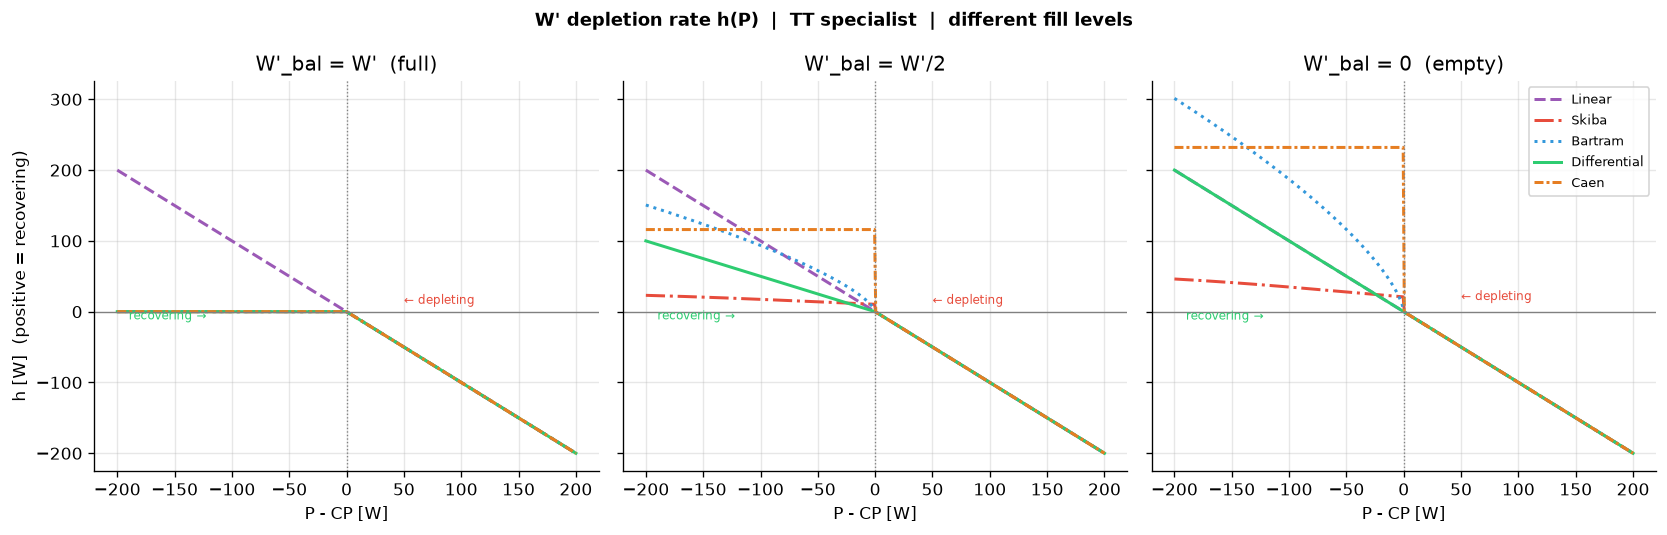

In [14]:
# W' depletion rate h(P) for all 4 models at different fill levels
# Reference rider: TT specialist
cp_ref = ARCHETYPES["TT specialist"]["cp"]
wp_ref = ARCHETYPES["TT specialist"]["w_prime"]

P_range = np.linspace(cp_ref - 200, cp_ref + 200, 400)
fill_levels = [1.0, 0.5, 0.0]  # W'_bal / W'
fill_labels = ["W'_bal = W'  (full)", "W'_bal = W'/2", "W'_bal = 0  (empty)"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig.suptitle("W' depletion rate h(P)  |  TT specialist  |  different fill levels",
             fontsize=11, fontweight="bold")

for ax, fill, label in zip(axes, fill_levels, fill_labels):
    wb = fill * wp_ref
    for mname, model in W_PRIME_MODELS.items():
        h_arr = [model.h(float(p), wb, cp_ref, wp_ref) for p in P_range]
        ax.plot(P_range - cp_ref, h_arr,
                color=MODEL_COLORS[mname], ls=MODEL_STYLES[mname],
                lw=1.8, label=mname)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8, ls=":")
    ax.set_xlabel("P - CP [W]")
    ax.set_title(label)
    ax.annotate("← depleting", xy=(50, ax.get_ylim()[1]*0.05 if ax.get_ylim()[1] > 0 else 5),
                fontsize=7, color="#e74c3c")
    ax.annotate("recovering →", xy=(-190, ax.get_ylim()[0]*0.05 if ax.get_ylim()[0] < 0 else -5),
                fontsize=7, color="#2ecc71")

axes[0].set_ylabel("h [W]  (positive = recovering)")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

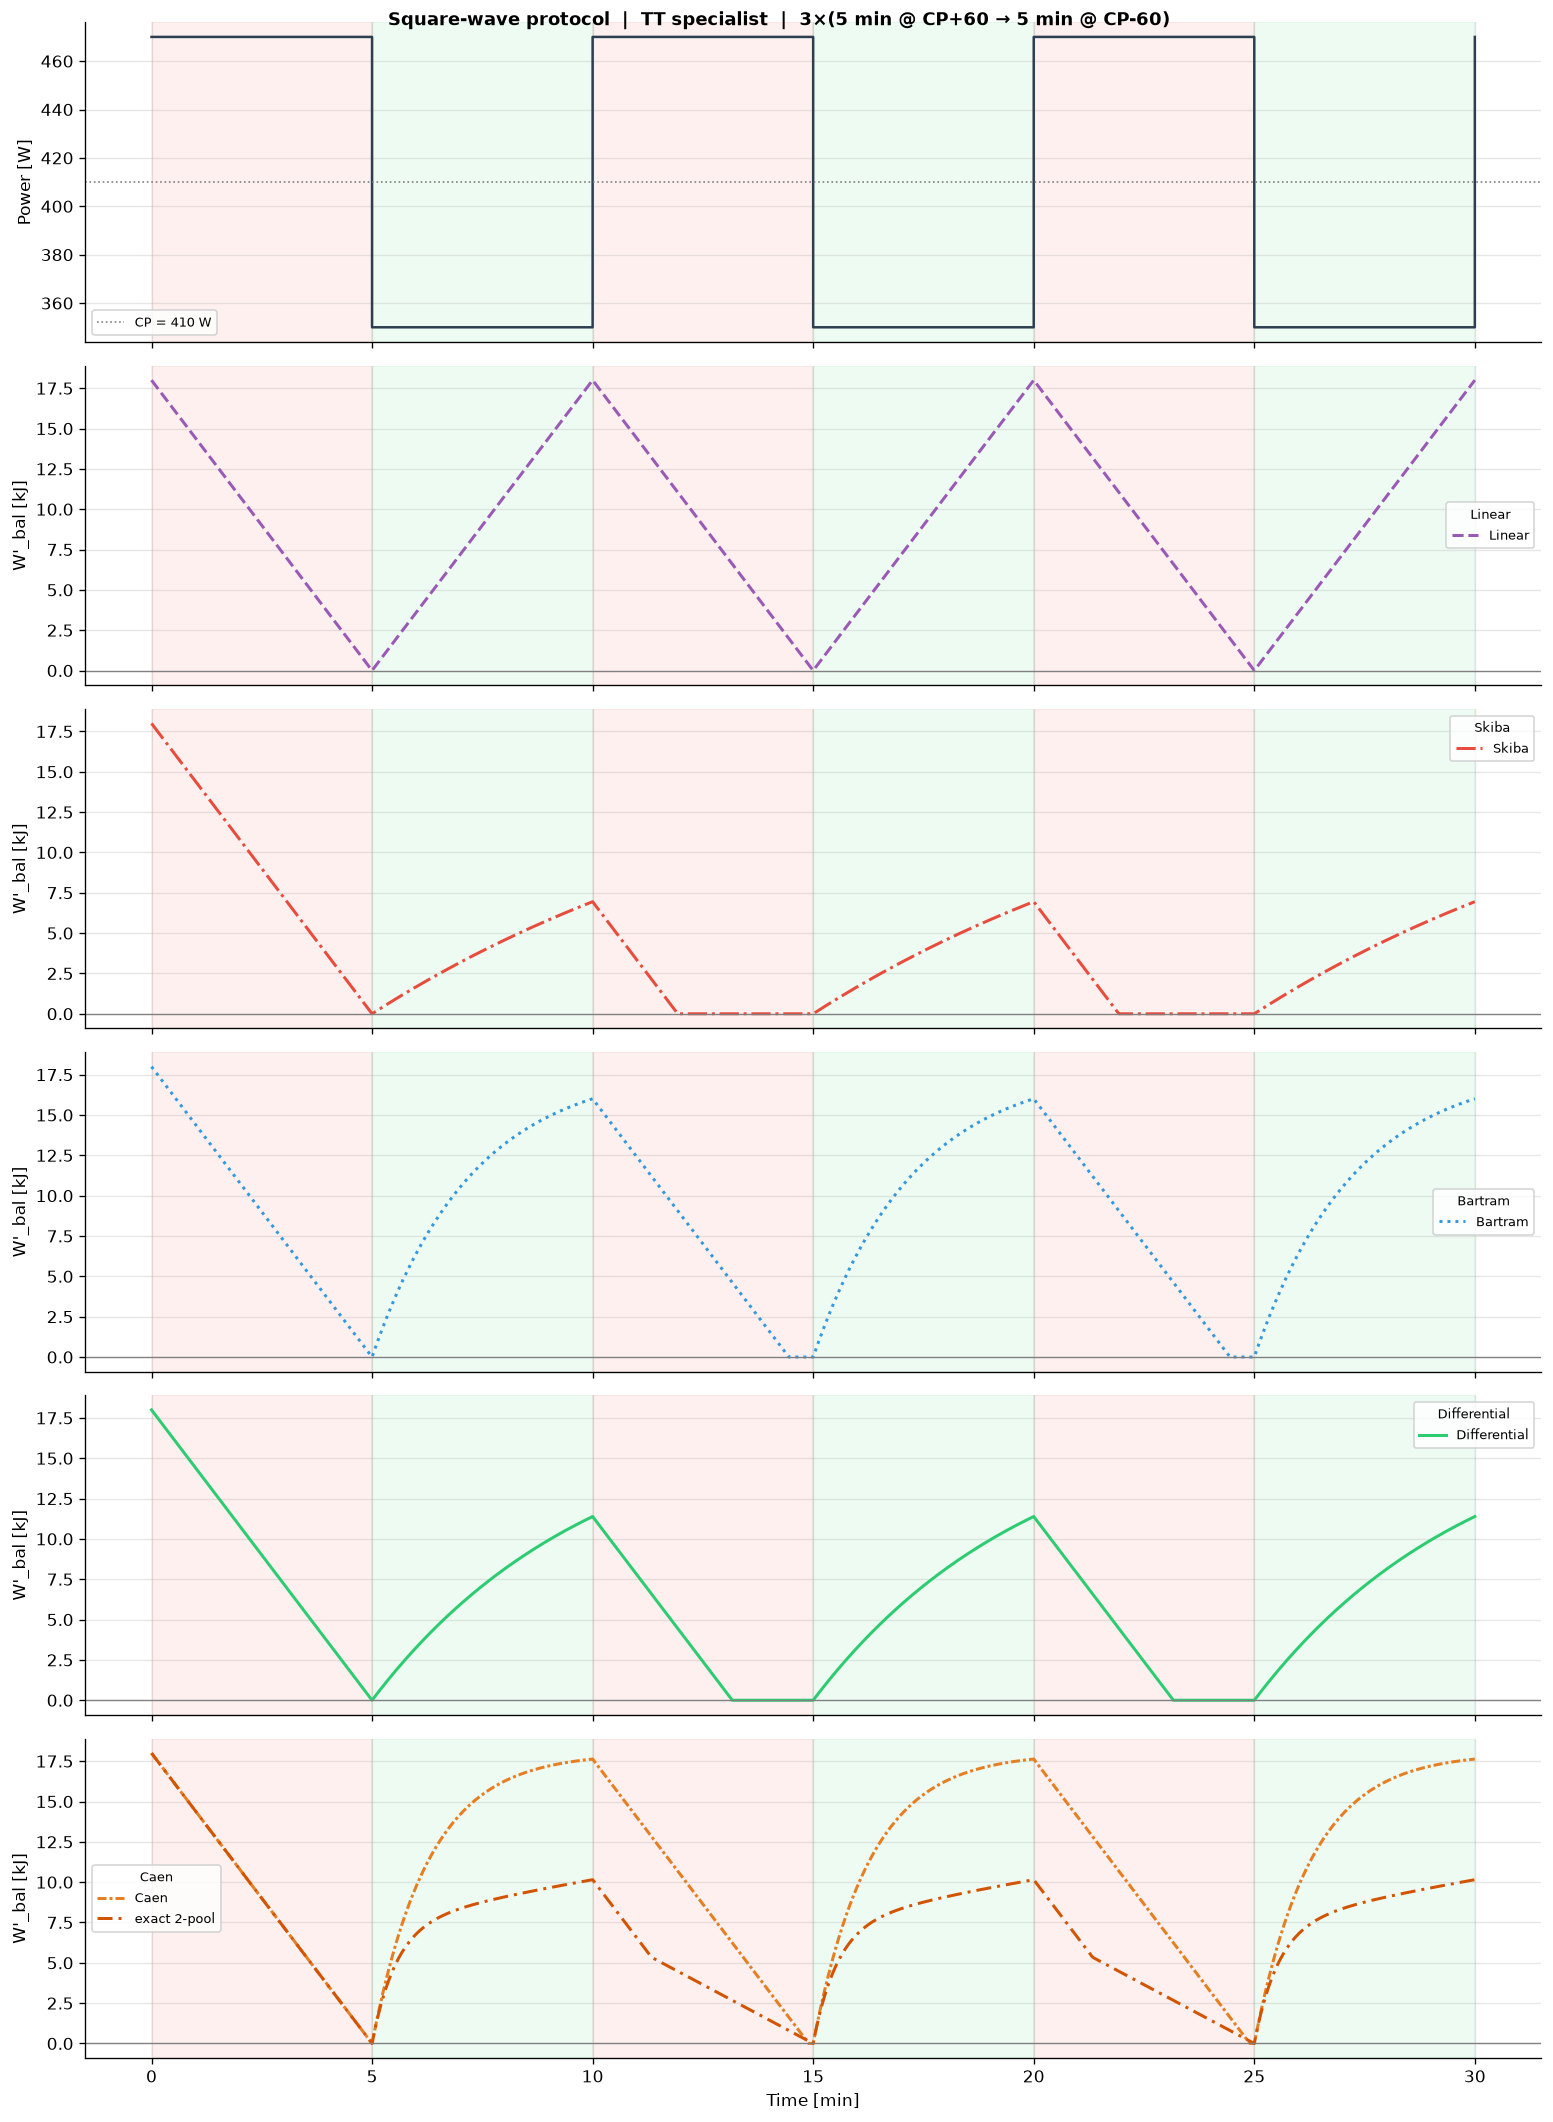

In [15]:
# Square-wave effort × 3 repetitions: 5 min @ CP+60W → 5 min @ CP-60W
dt_s = 1.0
effort_s, recovery_s, n_reps = 300, 300, 3
T_total = (effort_s + recovery_s) * n_reps
t_arr_sw = np.arange(0, T_total + dt_s, dt_s)

# Power protocol
P_effort, P_recover = cp_ref + 60, cp_ref - 60
P_sw = np.where((t_arr_sw % (effort_s + recovery_s)) < effort_s, P_effort, P_recover)

model_names = list(W_PRIME_MODELS.keys())
n_models = len(model_names)
n_rows = 1 + n_models  # power + one row per model

fig, axes = plt.subplots(n_rows, 1, figsize=(13, 3 * n_rows), sharex=True)
fig.suptitle(f"Square-wave protocol  |  TT specialist  |  {n_reps}×(5 min @ CP+60 → 5 min @ CP-60)",
             fontsize=11, fontweight="bold")

ax_p = axes[0]
axs_w = axes[1:]

def _shade_bands(ax):
    for rep in range(n_reps):
        t0 = rep * (effort_s + recovery_s)
        ax.axvspan(t0/60, (t0+effort_s)/60, alpha=0.08, color="#e74c3c")
        ax.axvspan((t0+effort_s)/60, (t0+effort_s+recovery_s)/60, alpha=0.08, color="#2ecc71")

# Power subplot
ax_p.step(t_arr_sw / 60, P_sw, where="post", color="#2c3e50", lw=1.5)
ax_p.axhline(cp_ref, color="gray", ls=":", lw=1, label=f"CP = {cp_ref:.0f} W")
_shade_bands(ax_p)
ax_p.set_ylabel("Power [W]")
ax_p.legend(fontsize=8)

# One W'_bal panel per model
caen = W_PRIME_MODELS["Caen"]
for ax_w, mname in zip(axs_w, model_names):
    model = W_PRIME_MODELS[mname]
    wb = wp_ref
    wb_arr = [wb]
    for p in P_sw[:-1]:
        h = model.h(float(p), wb, cp_ref, wp_ref)
        wb = max(0.0, min(wp_ref, wb + h * dt_s))
        wb_arr.append(wb)
    ax_w.plot(t_arr_sw / 60, np.array(wb_arr) / 1000,
              color=MODEL_COLORS[mname], ls=MODEL_STYLES[mname],
              lw=1.8, label=mname)

    if mname == "Caen":
        g_f, g_s = 0.0, 0.0
        wb_arr_exact = [wp_ref - g_f - g_s]
        for p in P_sw[:-1]:
            dg_f, dg_s = caen.h_pools(float(p), g_f, g_s, cp_ref)
            g_f = max(0.0, min(caen.a_f * wp_ref, g_f + dg_f * dt_s))
            g_s = max(0.0, min(caen.a_s * wp_ref, g_s + dg_s * dt_s))
            wb_arr_exact.append(wp_ref - g_f - g_s)
        ax_w.plot(t_arr_sw / 60, np.array(wb_arr_exact) / 1000,
                  color=CAEN_EXACT_COLOR, ls=CAEN_EXACT_STYLE,
                  lw=1.8, label="exact 2-pool")

    _shade_bands(ax_w)
    ax_w.axhline(0, color="gray", lw=0.8)
    ax_w.set_ylabel("W'_bal [kJ]")
    ax_w.legend(fontsize=8, title=mname, title_fontsize=8)

axes[-1].set_xlabel("Time [min]")
plt.tight_layout()
plt.show()

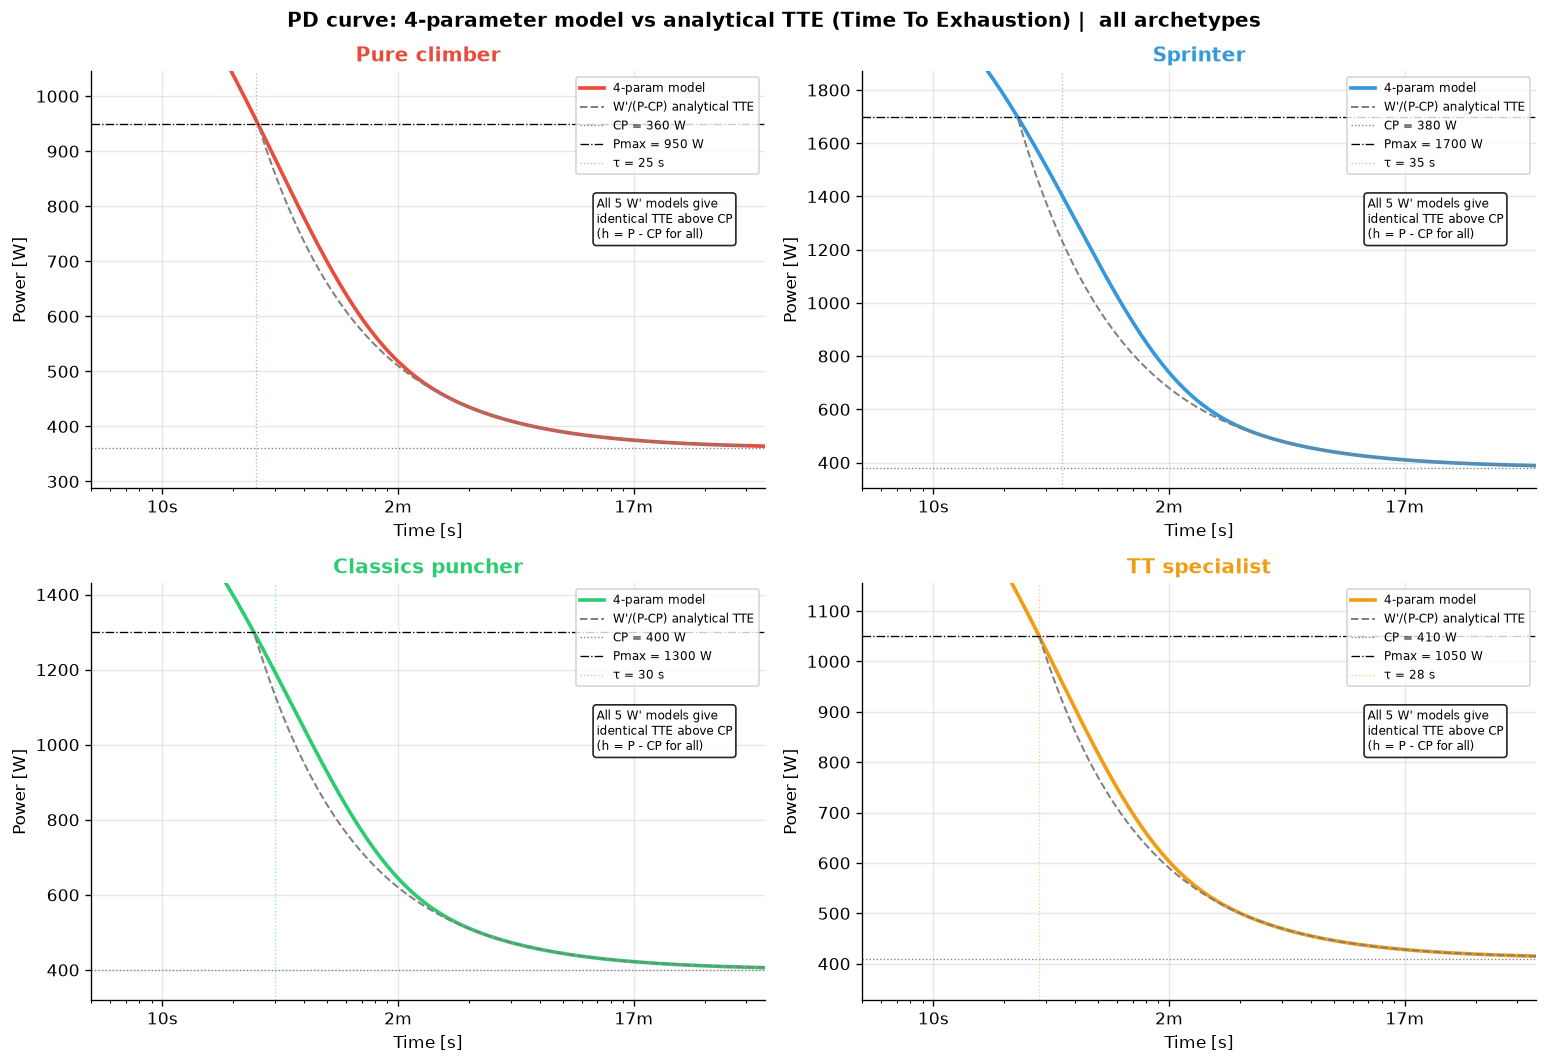

In [16]:
# TTE (Time To Exhaustion) from time-domain integration per W' model vs 2-parameter analytical
# NB: above CP all 4 models share h = P - CP  → identical TTE
# Comparison therefore highlights: 4-param PD curve, analytical TTE, and small launch-time offset
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
fig.suptitle("PD curve: 4-parameter model vs analytical TTE (Time To Exhaustion) |  all archetypes",
             fontsize=12, fontweight="bold")

for ax, (name, col) in zip(axes, zip(ARCHETYPE_NAMES, ARCH_COLORS)):
    a = ARCHETYPES[name]
    cp, wp, pmax, tau = a["cp"], a["w_prime"], a["p_max"], a["tau"]

    # 4-parameter PD model: P(t) → invert to get t(P)
    t_pd = np.logspace(np.log10(5), np.log10(3600), 400)
    p_pd = pd_4param(t_pd, cp, wp, pmax, tau)

    # Analytical TTE (2-parameter, no launch): t = W'/(P-CP)
    P_above = np.linspace(cp + 5, pmax, 200)
    tte_2p  = wp / (P_above - cp)  # ignores launch time

    # TTE from time-domain ODE (h = P-CP, all models identical above CP)
    # Same as 2-parameter since depletion branch is h = P-CP for all models
    # (shown as single 'ODE models' trace – all overlay perfectly)

    ax.plot(t_pd, p_pd, color=col, lw=2.2, label="4-param model")
    ax.plot(tte_2p, P_above, color="gray", lw=1.2, ls="--", label="W'/(P-CP) analytical TTE")
    ax.axhline(cp,   color="gray",  lw=0.8, ls=":", label=f"CP = {cp:.0f} W")
    ax.axhline(pmax, color="black", lw=0.8, ls="-.", label=f"Pmax = {pmax:.0f} W")
    ax.axvline(tau,  color=col, lw=0.8, ls=":", alpha=0.5, label=f"τ = {tau:.0f} s")

    ax.set_xscale("log")
    ax.set_xlim(5, 3600)
    ax.set_ylim(cp * 0.8, pmax * 1.1)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Power [W]")
    ax.set_title(name, color=col, fontweight="bold")
    ax.legend(fontsize=7, loc="upper right")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x:.0f}s" if x < 60 else f"{x/60:.0f}m" if x < 3600 else "1h"))
    ax.annotate(
        "All 5 W' models give\nidentical TTE above CP\n(h = P - CP for all)",
        xy=(0.75, 0.60), xycoords="axes fraction", fontsize=7,
        bbox=dict(boxstyle="round", fc="white", alpha=0.85))

plt.tight_layout()
plt.show()

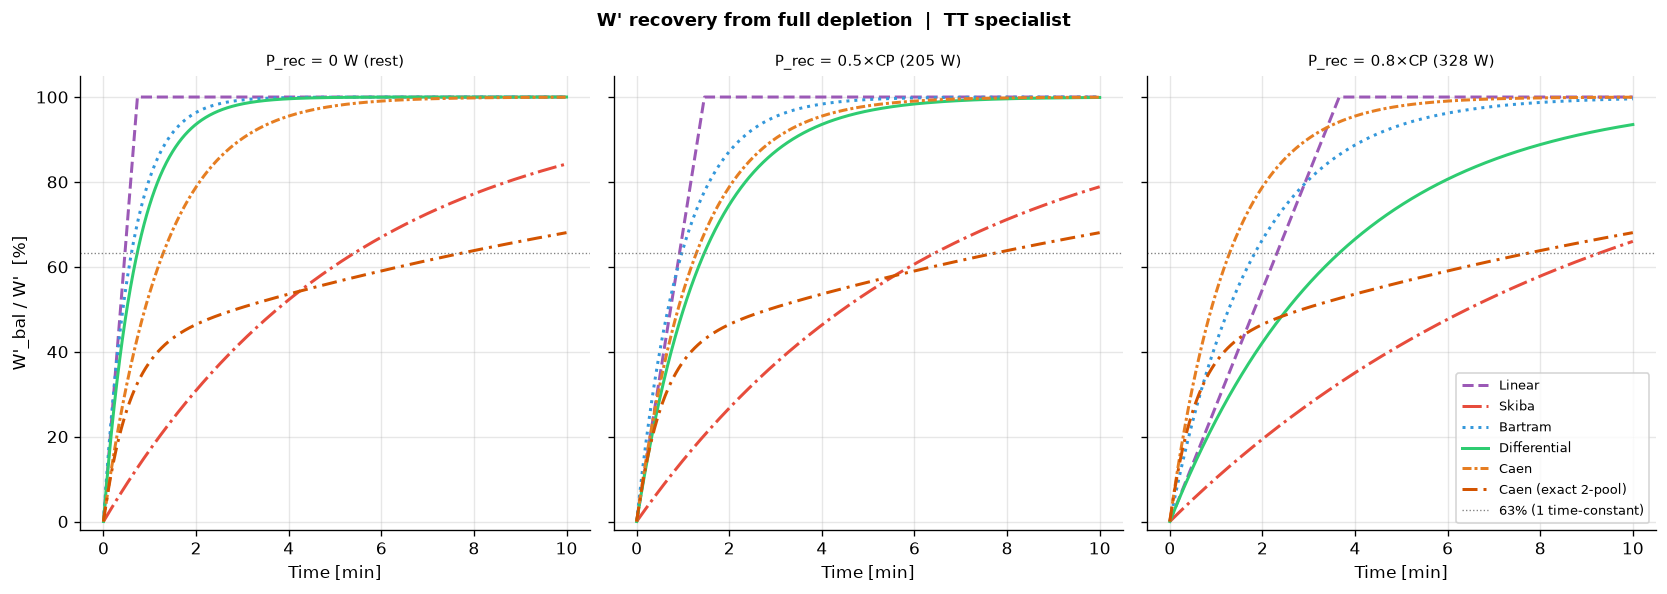

In [17]:
# Recovery from full depletion at different P_recovery levels
dt_r = 0.5  # s
T_rec = 600  # s
t_rec = np.arange(0, T_rec + dt_r, dt_r)
P_rec_levels = [0.0, 0.5 * cp_ref, 0.8 * cp_ref]
P_rec_labels  = ["P_rec = 0 W (rest)", f"P_rec = 0.5×CP ({0.5*cp_ref:.0f} W)",
                 f"P_rec = 0.8×CP ({0.8*cp_ref:.0f} W)"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle("W' recovery from full depletion  |  TT specialist", fontsize=11, fontweight="bold")

caen = W_PRIME_MODELS["Caen"]
for ax, p_rec, p_label in zip(axes, P_rec_levels, P_rec_labels):
    for mname, model in W_PRIME_MODELS.items():
        wb = 0.0
        wb_arr = [wb]
        for _ in t_rec[:-1]:
            h = model.h(p_rec, wb, cp_ref, wp_ref)
            wb = max(0.0, min(wp_ref, wb + h * dt_r))
            wb_arr.append(wb)
        wb_frac = np.array(wb_arr) / wp_ref * 100
        ax.plot(t_rec / 60, wb_frac,
                color=MODEL_COLORS[mname], ls=MODEL_STYLES[mname],
                lw=1.8, label=mname)

    # Caen exact two-pool integration (Kernel B): tracks g_f and g_s independently
    g_f, g_s = caen.a_f * wp_ref, caen.a_s * wp_ref
    wb_arr_exact = [wp_ref - g_f - g_s]
    for _ in t_rec[:-1]:
        dg_f, dg_s = caen.h_pools(p_rec, g_f, g_s, cp_ref)
        g_f = max(0.0, min(caen.a_f * wp_ref, g_f + dg_f * dt_r))
        g_s = max(0.0, min(caen.a_s * wp_ref, g_s + dg_s * dt_r))
        wb_arr_exact.append(wp_ref - g_f - g_s)
    wb_frac_exact = np.array(wb_arr_exact) / wp_ref * 100
    ax.plot(t_rec / 60, wb_frac_exact,
            color=CAEN_EXACT_COLOR, ls=CAEN_EXACT_STYLE,
            lw=1.8, label="Caen (exact 2-pool)")

    ax.axhline(63.2, color="gray", lw=0.8, ls=":", label="63% (1 time-constant)")
    ax.set_title(p_label, fontsize=9)
    ax.set_xlabel("Time [min]")
    ax.set_ylim(-2, 105)

axes[0].set_ylabel("W'_bal / W'  [%]")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## §5 — W' as a function of the course

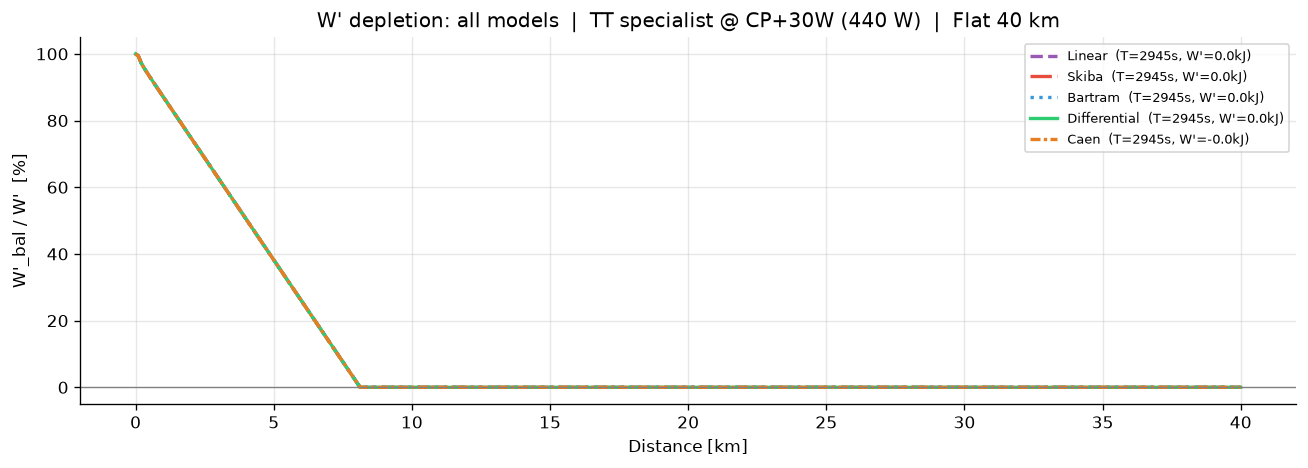

In [18]:
# Synthetic flat course: all 4 W' models at CP+30W  (TT specialist)
p_supra = cp_ref + 30

fig, ax = plt.subplots(figsize=(11, 4))
results_flat_models = {}
for mname, model in W_PRIME_MODELS.items():
    rider_m = make_rider(ARCHETYPES["TT specialist"], model=model)
    res = SIM.simulate(rider_m, flat_course, CALM_WIND, np.full(N_FLAT, float(p_supra)))
    results_flat_models[mname] = res
    wb_pct = res.w_prime_bal_J / ARCHETYPES["TT specialist"]["w_prime"] * 100
    ax.plot(res.s_m / 1000, wb_pct,
            color=MODEL_COLORS[mname], ls=MODEL_STYLES[mname],
            lw=2, label=f"{mname}  (T={res.time_total_s:.0f}s, W'={res.w_prime_bal_J[-1]/1000:.1f}kJ)")

ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("Distance [km]")
ax.set_ylabel("W'_bal / W'  [%]")
ax.set_title(f"W' depletion: all models  |  TT specialist @ CP+30W ({p_supra:.0f} W)  |  Flat 40 km")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

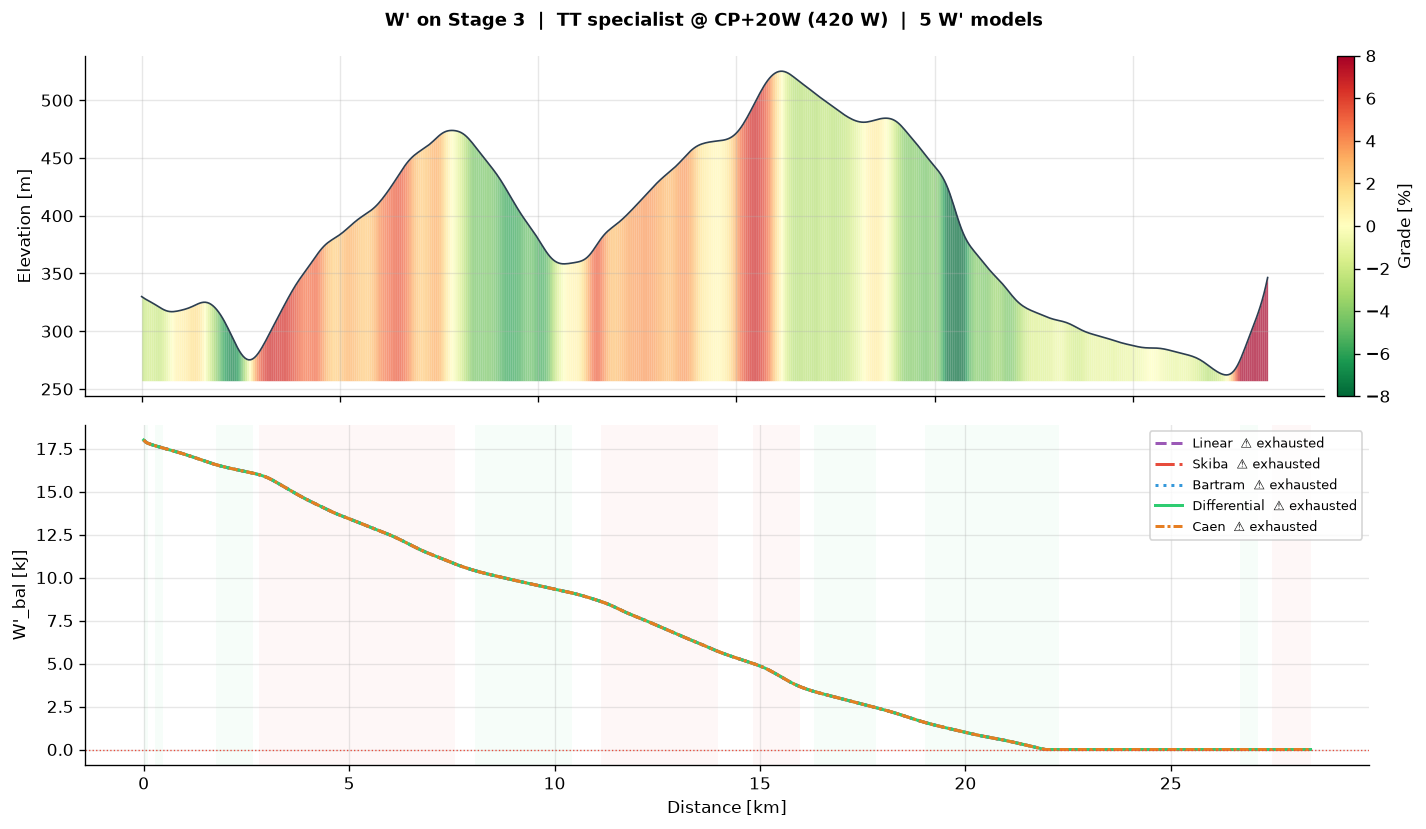

In [19]:
# GPX course: W'_bal(s) for all 5 models at CP+10W (TT specialist)
p_gpx_supra = cp_ref + 10
grade_bg = np.tan(gpx_course.theta_rad) * 100

fig, (ax_e, ax_w) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle(f"W' on Stage 3  |  TT specialist @ CP+20W ({p_gpx_supra:.0f} W)  |  5 W' models",
             fontsize=11, fontweight="bold")

# Top: elevation coloured by grade
cmap_g = plt.get_cmap("RdYlGn_r")
norm_g = plt.Normalize(-8, 8)
for i in range(len(km_gpx) - 1):
    ax_e.fill_between(km_gpx[i:i+2], elev_gpx[i:i+2], elev_gpx.min() - 5,
                      color=cmap_g(norm_g(grade_bg[i])), lw=0, alpha=0.7)
ax_e.plot(km_gpx, elev_gpx, color="#2c3e50", lw=1)
ax_e.set_ylabel("Elevation [m]")
sm = plt.cm.ScalarMappable(cmap=cmap_g, norm=norm_g)
sm.set_array([])
fig.colorbar(sm, ax=ax_e, orientation="vertical", fraction=0.025, pad=0.01, label="Grade [%]")

# Bottom: W'_bal per model
for mname, model in W_PRIME_MODELS.items():
    rider_m = make_rider(ARCHETYPES["TT specialist"], model=model)
    res = SIM.simulate(rider_m, gpx_course, CALM_WIND,
                       np.full(len(gpx_course.s_m), float(p_gpx_supra)))
    ax_w.plot(res.s_m / 1000, res.w_prime_bal_J / 1000,
              color=MODEL_COLORS[mname], ls=MODEL_STYLES[mname],
              lw=1.8, label=f"{mname}{'  ⚠ exhausted' if res.w_prime_violated else ''}")

ax_w.axhline(0, color="#e74c3c", lw=0.8, ls=":")
ax_w.set_ylabel("W'_bal [kJ]")
ax_w.set_xlabel("Distance [km]")
ax_w.legend(fontsize=8)

# Grade-shade background on ax_w
for i in range(len(km_gpx) - 1):
    if grade_bg[i] > 2:
        ax_w.axvspan(km_gpx[i], km_gpx[i+1], alpha=0.04, color="#e74c3c", lw=0)
    elif grade_bg[i] < -2:
        ax_w.axvspan(km_gpx[i], km_gpx[i+1], alpha=0.04, color="#2ecc71", lw=0)

plt.tight_layout()
plt.show()

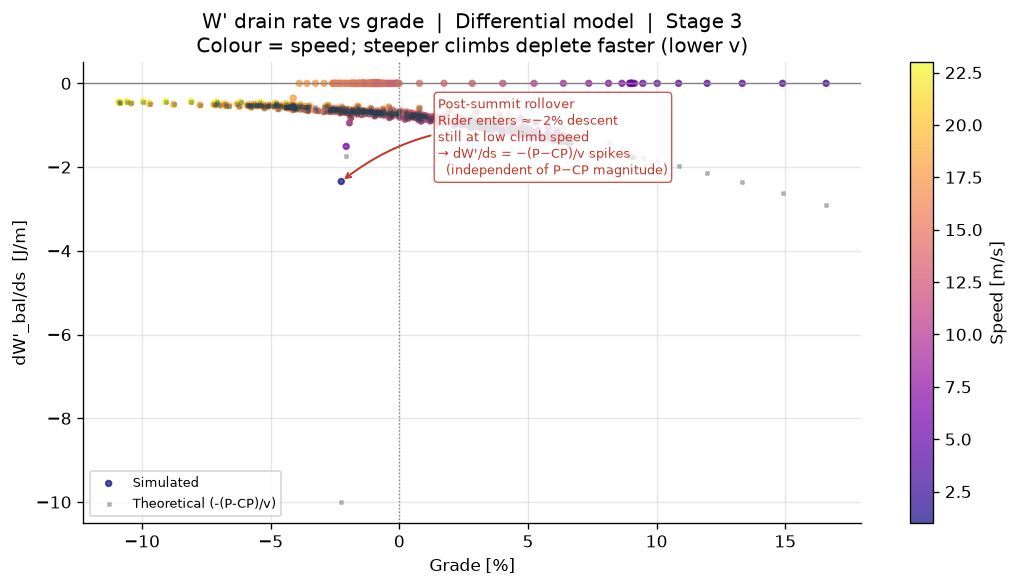

In [20]:
# W' drain rate dW'_bal/ds vs road angle (Differential model, TT specialist)
rider_diff = make_rider(ARCHETYPES["TT specialist"], model=DifferentialModel())
res_drain = SIM.simulate(rider_diff, gpx_course, CALM_WIND,
                          np.full(len(gpx_course.s_m), float(p_gpx_supra)))

dw_ds_sim  = np.diff(res_drain.w_prime_bal_J) / np.diff(res_drain.s_m)  # [J/m]
theta_mid  = 0.5 * (gpx_course.theta_rad[:-1] + gpx_course.theta_rad[1:])
grade_mid  = np.tan(theta_mid) * 100
v_mid      = 0.5 * (res_drain.v_m_per_s[:-1] + res_drain.v_m_per_s[1:])

# Theoretical: dW'/ds = -h/v = -(P-CP)/v  (only drain part shown for P > CP)
dw_ds_theory = np.where(
    p_gpx_supra > cp_ref,
    -(p_gpx_supra - cp_ref) / np.maximum(v_mid, 1e-3),
    0.0
)

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(grade_mid, dw_ds_sim, c=v_mid, cmap="plasma", s=12, alpha=0.7, label="Simulated")
ax.scatter(grade_mid, dw_ds_theory, color="#2c3e50", s=5, alpha=0.4, marker="x", label="Theoretical (-(P-CP)/v)")
plt.colorbar(sc, ax=ax, label="Speed [m/s]")
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8, ls=":")
ax.set_xlabel("Grade [%]")
ax.set_ylabel("dW'_bal/ds  [J/m]")
ax.set_title("W' drain rate vs grade  |  Differential model  |  Stage 3\n"
             "Colour = speed; steeper climbs deplete faster (lower v)")
ax.legend(fontsize=8)

# Annotate the dip at ~-2% grade.
# dW'/ds = -(P-CP)/v is purely speed-driven. The -2% grade bucket spans a wide
# speed range because these segments include post-summit rollovers: the rider
# crests a climb at low speed and immediately enters a shallow descent at ~-2%,
# so v is still low → large |dW'/ds|. The effect is independent of P-CP magnitude.
dip_mask = (grade_mid > -3.5) & (grade_mid < -0.5)
if dip_mask.any():
    dip_x = grade_mid[dip_mask][np.argmin(dw_ds_sim[dip_mask])]
    dip_y = dw_ds_sim[dip_mask].min()
    ax.annotate(
        "Post-summit rollover\n"
        "Rider enters ≈−2% descent\n"
        "still at low climb speed\n"
        "→ dW'/ds = −(P−CP)/v spikes\n"
        "  (independent of P−CP magnitude)",
        xy=(dip_x, dip_y),
        xytext=(1.5, dip_y * 0.55),
        fontsize=7.5,
        color="#c0392b",
        ha="left",
        va="center",
        arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2,
                        connectionstyle="arc3,rad=0.25"),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#c0392b", alpha=0.85, lw=0.8),
    )

plt.tight_layout()
plt.show()

---
## §6 — Rider archetype simulations

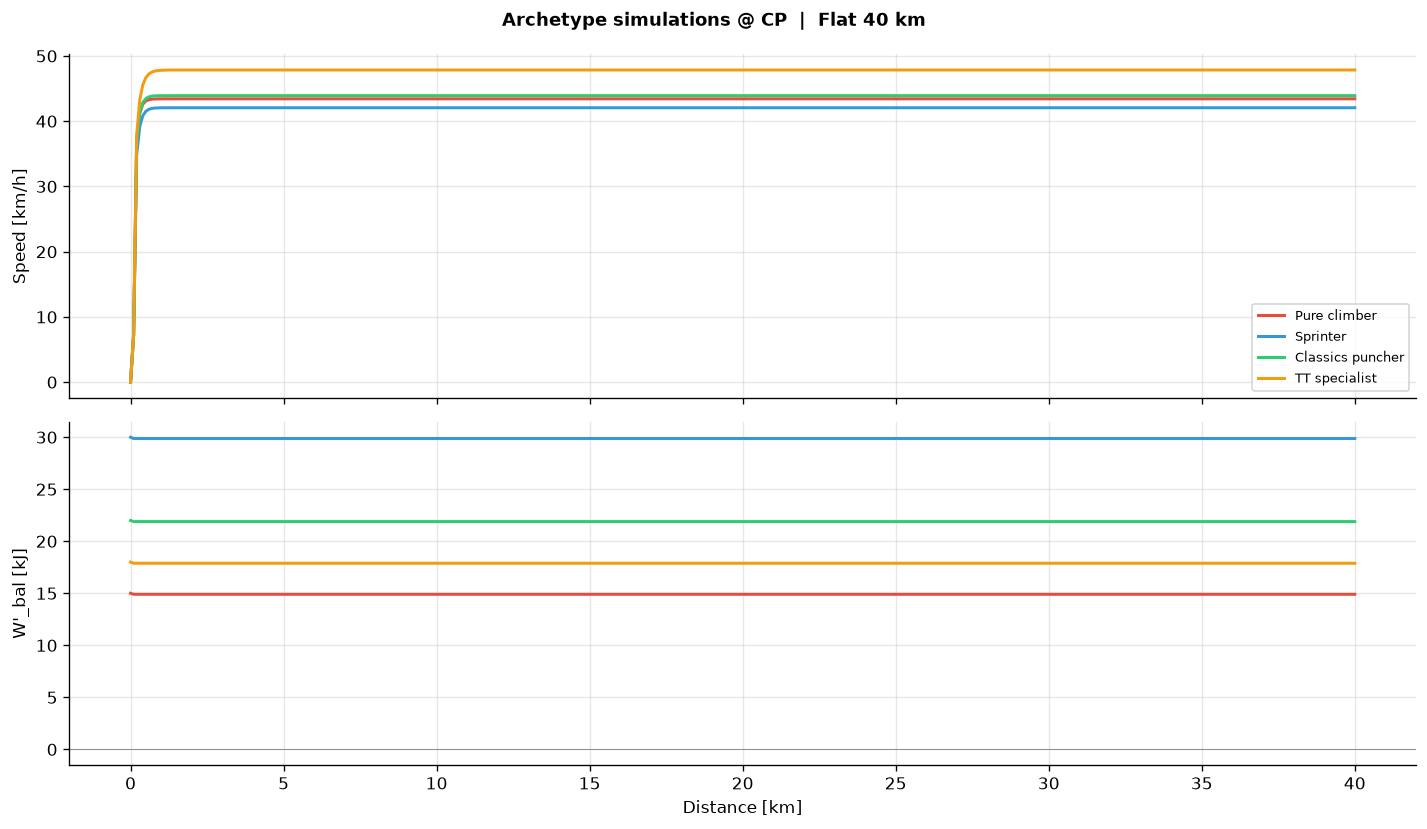

,Total time [s],Mean speed [km/h],W'_bal finish [kJ],W' used [%]
Archetype,,,,
Pure climber,3323.8,43.32,14.90,0.6
Sprinter,3432.0,41.96,29.87,0.4
Classics puncher,3287.3,43.81,21.89,0.5
TT specialist,3020.1,47.68,17.89,0.6


In [21]:
# Each archetype at their own CP on flat course (Differential model)
flat_results = {}
for name, rider in RIDERS.items():
    cp = ARCHETYPES[name]["cp"]
    flat_results[name] = SIM.simulate(rider, flat_course, CALM_WIND,
                                       np.full(N_FLAT, float(cp)))

fig, (ax_v, ax_w) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Archetype simulations @ CP  |  Flat 40 km", fontsize=11, fontweight="bold")

for (name, res), col in zip(flat_results.items(), ARCH_COLORS):
    ax_v.plot(res.s_m / 1000, res.v_m_per_s * 3.6, color=col, lw=1.8, label=name)
    ax_w.plot(res.s_m / 1000, res.w_prime_bal_J / 1000, color=col, lw=1.8)

ax_v.set_ylabel("Speed [km/h]")
ax_v.legend(fontsize=8)
ax_w.set_ylabel("W'_bal [kJ]")
ax_w.set_xlabel("Distance [km]")
ax_w.axhline(0, color="gray", lw=0.5)
plt.tight_layout()
plt.show()

# Summary table
rows_flat = []
for name, res in flat_results.items():
    wp0 = ARCHETYPES[name]["w_prime"]
    rows_flat.append({
        "Archetype":         name,
        "Total time [s]": round(res.time_total_s, 1),
        "Mean speed [km/h]": round(flat_course.s_m[-1] / res.time_total_s * 3.6, 2),
        "W'_bal finish [kJ]": round(res.w_prime_bal_J[-1] / 1000, 2),
        "W' used [%]": round((1 - res.w_prime_bal_J[-1] / wp0) * 100, 1),
    })
pd.DataFrame(rows_flat).set_index("Archetype")

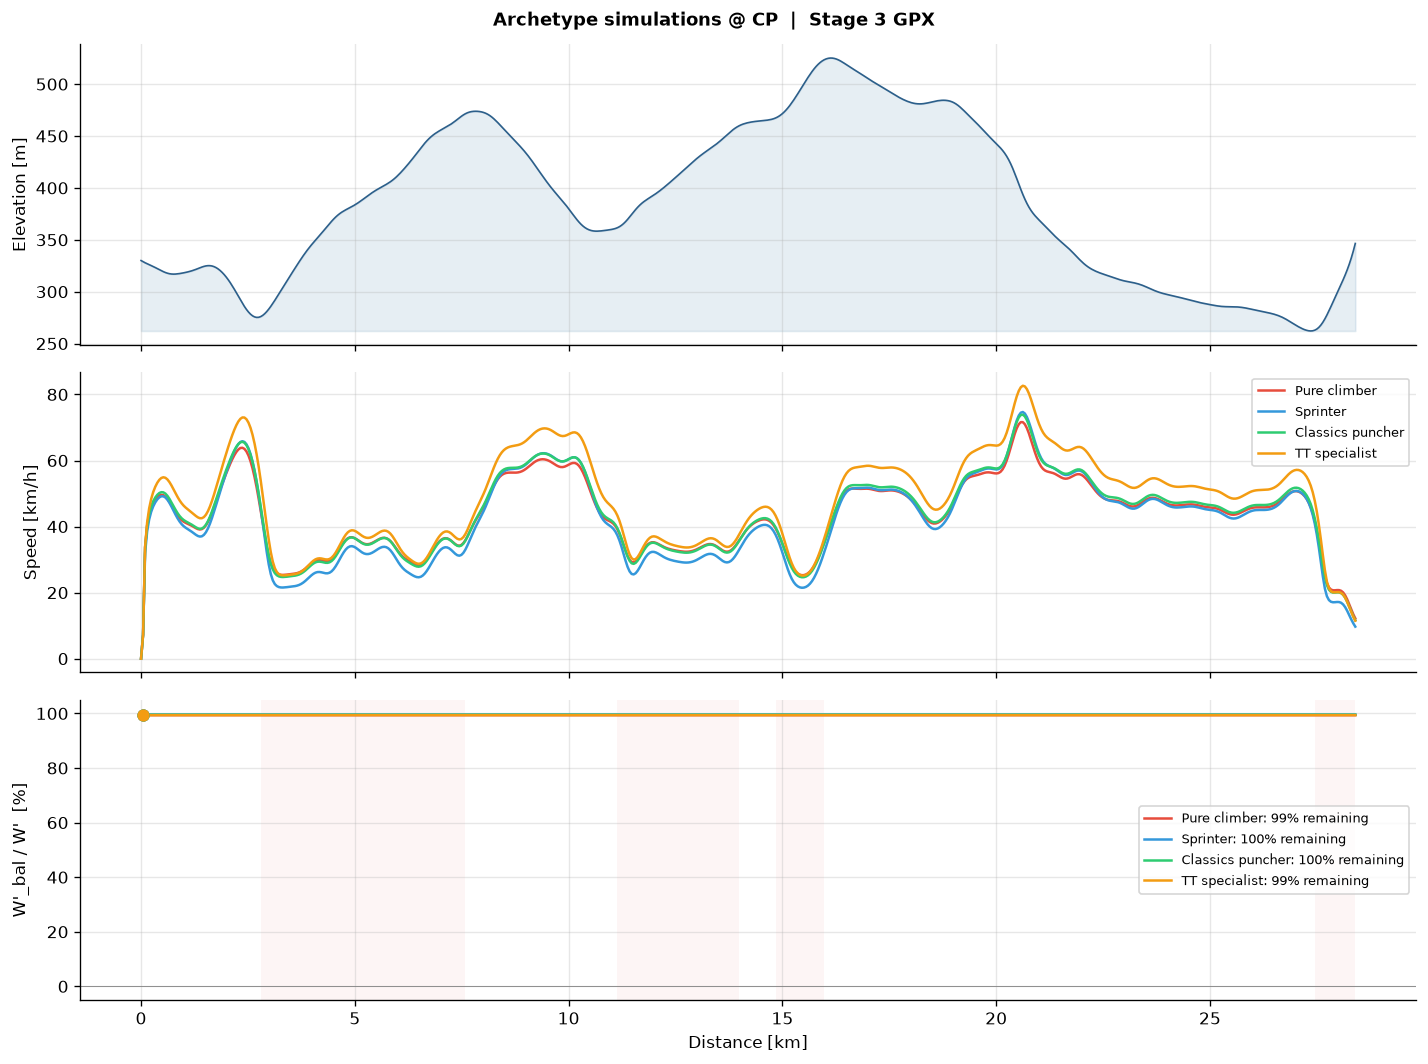

In [22]:
# Each archetype at their own CP on GPX Stage 3 (Differential model)
gpx_results = {}
for name, rider in RIDERS.items():
    cp = ARCHETYPES[name]["cp"]
    n_gpx = len(gpx_course.s_m)
    gpx_results[name] = SIM.simulate(rider, gpx_course, CALM_WIND,
                                      np.full(n_gpx, float(cp)))

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Archetype simulations @ CP  |  Stage 3 GPX", fontsize=11, fontweight="bold")

axes[0].fill_between(km_gpx, elev_gpx, elev_gpx.min(), alpha=0.15, color="#5b8eb5")
axes[0].plot(km_gpx, elev_gpx, color="#2c5f8a", lw=1)
axes[0].set_ylabel("Elevation [m]")

for (name, res), col in zip(gpx_results.items(), ARCH_COLORS):
    axes[1].plot(res.s_m / 1000, res.v_m_per_s * 3.6, color=col, lw=1.5, label=name)

axes[1].set_ylabel("Speed [km/h]")
axes[1].legend(fontsize=8)

for (name, res), col in zip(gpx_results.items(), ARCH_COLORS):
    wp0 = ARCHETYPES[name]["w_prime"]
    wb_pct = res.w_prime_bal_J / wp0 * 100
    axes[2].plot(res.s_m / 1000, wb_pct, color=col, lw=1.5,
                 label=f"{name}: {wb_pct[-1]:.0f}% remaining")
    # Mark minimum W'_bal
    idx_min = np.argmin(wb_pct)
    axes[2].scatter(res.s_m[idx_min]/1000, wb_pct[idx_min], color=col, s=40, zorder=5)

axes[2].axhline(0, color="gray", lw=0.5)
axes[2].set_ylabel("W'_bal / W'  [%]")
axes[2].set_xlabel("Distance [km]")
axes[2].legend(fontsize=8)

# Grade background on W' panel
for i in range(len(km_gpx) - 1):
    if grade_bg[i] > 2:
        axes[2].axvspan(km_gpx[i], km_gpx[i+1], alpha=0.05, color="#e74c3c", lw=0)

plt.tight_layout()
plt.show()

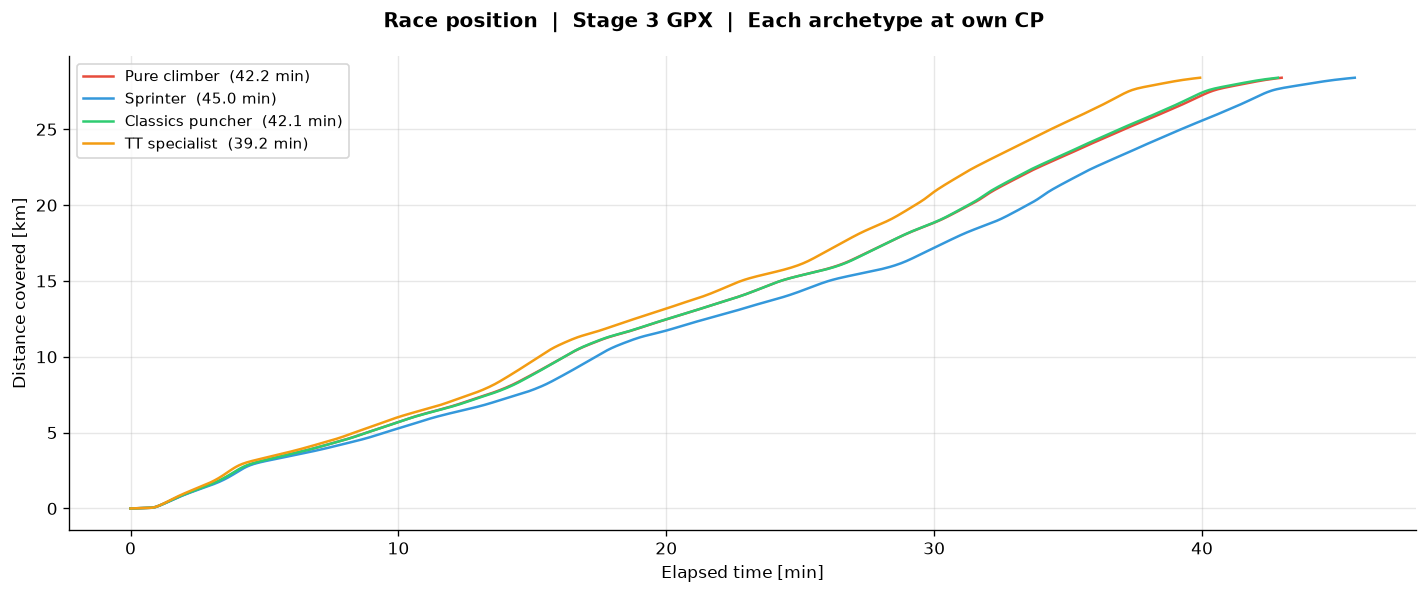

In [23]:
# Race position: distance covered vs. elapsed time (launch phase included)
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Race position  |  Stage 3 GPX  |  Each archetype at own CP",
             fontweight="bold")

for (name, res), col in zip(gpx_results.items(), ARCH_COLORS):
    ds      = np.diff(res.s_m)
    v_mid   = (res.v_m_per_s[:-1] + res.v_m_per_s[1:]) / 2
    dt      = ds / np.maximum(v_mid, 1e-6)
    # t=0 at standing start; first node is already at t_launch_s
    t_arr_s = res.t_launch_s + np.concatenate([[0.0], np.cumsum(dt)])
    ax.plot(t_arr_s / 60, res.s_m / 1000, color=col, lw=1.5,
            label=f"{name}  ({res.time_total_s / 60:.1f} min)")

ax.set_xlabel("Elapsed time [min]")
ax.set_ylabel("Distance covered [km]")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


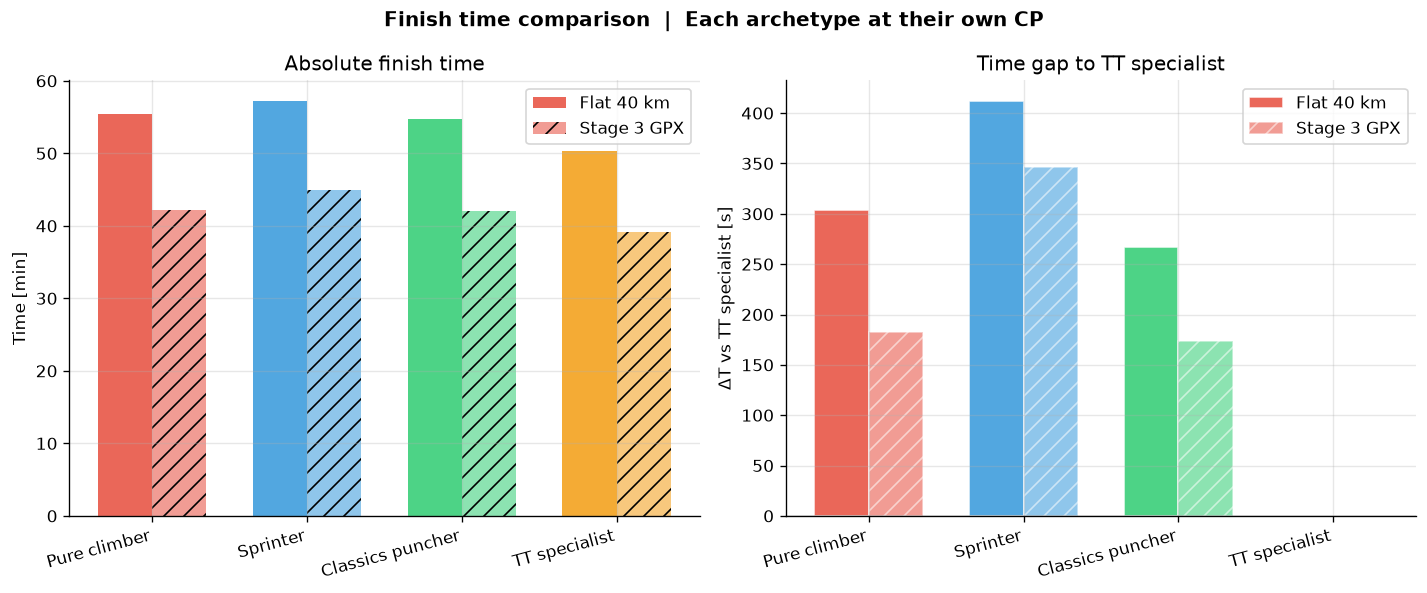

In [24]:
fig, (ax_t, ax_dt) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Finish time comparison  |  Each archetype at their own CP", fontweight="bold")

x = np.arange(len(ARCHETYPE_NAMES))
width = 0.35
flat_times = [flat_results[n].time_total_s / 60 for n in ARCHETYPE_NAMES]
gpx_times  = [gpx_results[n].time_total_s  / 60 for n in ARCHETYPE_NAMES]
ref_flat   = flat_results["TT specialist"].time_total_s / 60
ref_gpx    = gpx_results["TT specialist"].time_total_s  / 60

b1 = ax_t.bar(x - width/2, flat_times, width, label="Flat 40 km", alpha=0.85, color=ARCH_COLORS)
b2 = ax_t.bar(x + width/2, gpx_times,  width, label="Stage 3 GPX", alpha=0.55, color=ARCH_COLORS, hatch="//")
ax_t.set_xticks(x)
ax_t.set_xticklabels(ARCHETYPE_NAMES, rotation=15, ha="right")
ax_t.set_ylabel("Time [min]")
ax_t.legend()
ax_t.set_title("Absolute finish time")

dt_flat = [(t - ref_flat) * 60 for t in flat_times]
dt_gpx  = [(t - ref_gpx)  * 60 for t in gpx_times]
ax_dt.bar(x - width/2, dt_flat, width, label="Flat 40 km", alpha=0.85, color=ARCH_COLORS,
          edgecolor="white")
ax_dt.bar(x + width/2, dt_gpx,  width, label="Stage 3 GPX", alpha=0.55, color=ARCH_COLORS,
          hatch="//", edgecolor="white")
ax_dt.axhline(0, color="gray", lw=0.8)
ax_dt.set_xticks(x)
ax_dt.set_xticklabels(ARCHETYPE_NAMES, rotation=15, ha="right")
ax_dt.set_ylabel("ΔT vs TT specialist [s]")
ax_dt.legend()
ax_dt.set_title("Time gap to TT specialist")

plt.tight_layout()
plt.show()

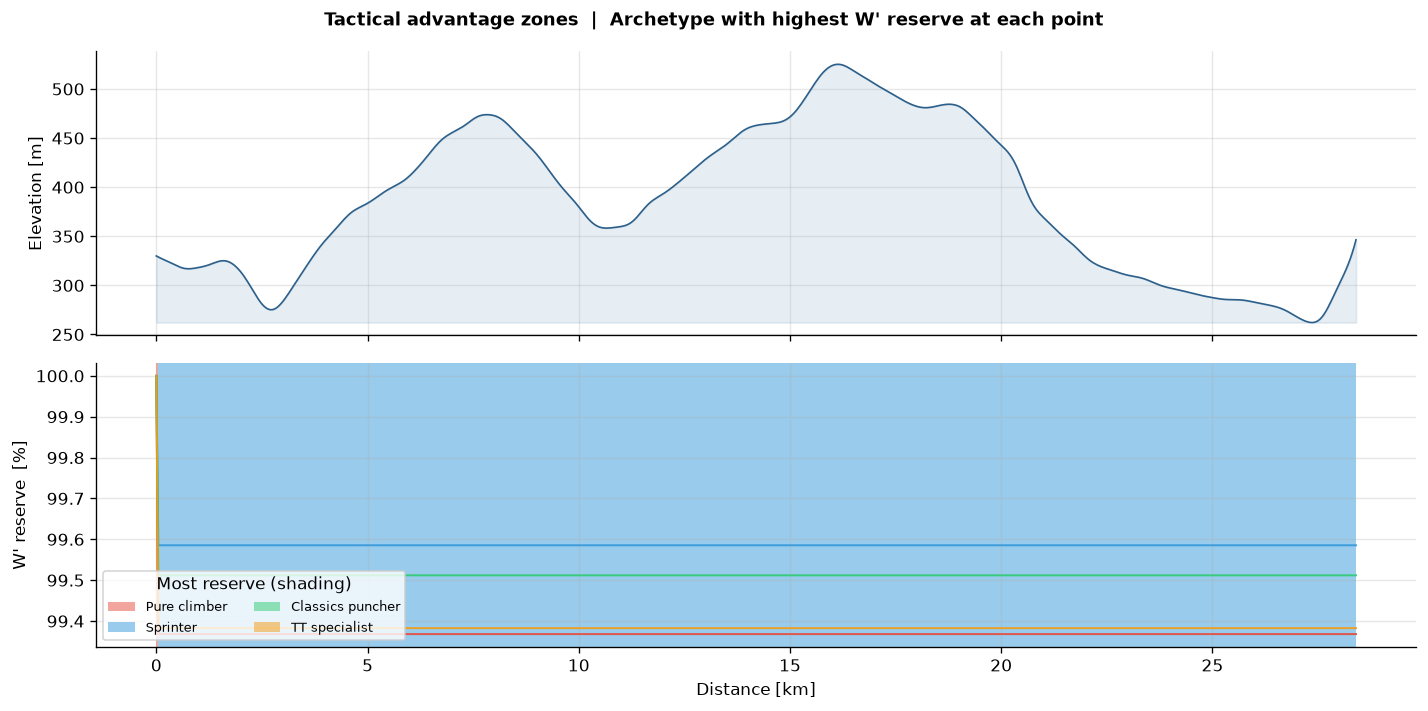

In [25]:
# Segment advantage zones: which archetype has most W' reserve (cheapest to pull)
# at each point along the GPX course → proxy for TTT tactical advantage
n_gpx = len(gpx_course.s_m)

# Fractional W' reserve per archetype along course
wb_frac_all = {}
for name, res in gpx_results.items():
    wp0 = ARCHETYPES[name]["w_prime"]
    wb_frac_all[name] = res.w_prime_bal_J / wp0

# At each node: which archetype has the highest fractional reserve?
wb_matrix = np.array([wb_frac_all[n] for n in ARCHETYPE_NAMES])  # (4, n_nodes)
best_arch  = np.argmax(wb_matrix, axis=0)  # index of best archetype at each node

fig, (ax_e2, ax_z) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle("Tactical advantage zones  |  Archetype with highest W' reserve at each point",
             fontsize=11, fontweight="bold")

ax_e2.fill_between(km_gpx, elev_gpx, elev_gpx.min(), alpha=0.15, color="#5b8eb5")
ax_e2.plot(km_gpx, elev_gpx, color="#2c5f8a", lw=1)
ax_e2.set_ylabel("Elevation [m]")

# Shade advantage zones
for i in range(len(km_gpx) - 1):
    col = ARCH_COLORS[best_arch[i]]
    ax_z.axvspan(km_gpx[i], km_gpx[i+1], alpha=0.5, color=col, lw=0)

# Overlay W' reserve lines
for (name, wb_f), col in zip(wb_frac_all.items(), ARCH_COLORS):
    ax_z.plot(km_gpx, wb_f * 100, color=col, lw=1.2, alpha=0.9, label=name)

ax_z.set_ylabel("W' reserve  [%]")
ax_z.set_xlabel("Distance [km]")
ax_z.legend(fontsize=8, ncol=2)

# Legend patches for advantage zones
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=col, alpha=0.5, label=name)
                  for name, col in zip(ARCHETYPE_NAMES, ARCH_COLORS)]
ax_z.legend(handles=legend_patches, fontsize=8, title="Most reserve (shading)",
            loc="lower left", ncol=2)

plt.tight_layout()
plt.show()

---
## §7 — Launch phase

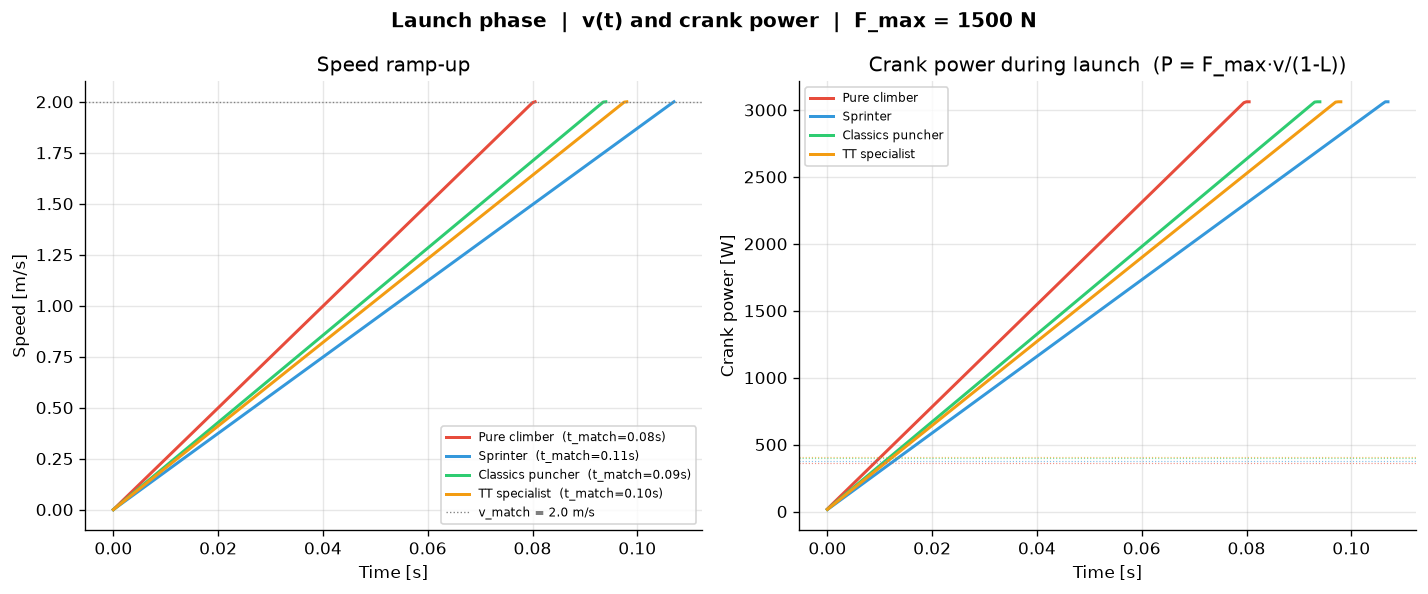

In [26]:
def simulate_launch(mass_kg, f_max_N, crr, cda_m2, rho, cp_W, l_drive,
                    v_match=2.0, dt=5e-4, theta=1e-3, v_w=0.1):
    """Python (non-Numba) launch integration that records the trajectory.

    Returns t_arr [s], v_arr [m/s], F_drive_arr [N], P_crank_arr [W].
    """
    v, t, s = 1e-6, 0.0, 0.0
    t_arr, v_arr, F_arr, P_arr = [t], [v], [], []

    while v < v_match:
        F_rr  = crr   * mass_kg * G_M_PER_S2 * math.cos(theta)
        F_ae  = 0.5   * rho * cda_m2 * (v + v_w) ** 2
        F_gv  = mass_kg * G_M_PER_S2 * math.sin(theta)
        F_net = f_max_N - F_rr - F_ae - F_gv
        a     = F_net / mass_kg
        v = min(v + a * dt, v_match)
        t += dt; s += v * dt
        t_arr.append(t); v_arr.append(v)
        p_crank = f_max_N * v / (1 - l_drive)
        F_arr.append(f_max_N); P_arr.append(p_crank)

    F_arr.append(F_arr[-1]); P_arr.append(P_arr[-1])
    return np.array(t_arr), np.array(v_arr), np.array(F_arr), np.array(P_arr)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Launch phase  |  v(t) and crank power  |  F_max = 1500 N", fontweight="bold")

for (name, col) in zip(ARCHETYPE_NAMES, ARCH_COLORS):
    a = ARCHETYPES[name]
    t_, v_, F_, P_ = simulate_launch(
        a["mass"], F_MAX_N, a["crr"], a["cda"], RHO_KG_PER_M3,
        a["cp"], L_DRIVE, v_match=V_MATCH_M_PER_S)
    axes[0].plot(t_, v_, color=col, lw=1.8, label=f"{name}  (t_match={t_[-1]:.2f}s)")
    axes[1].plot(t_, P_, color=col, lw=1.8, label=name)

axes[0].axhline(V_MATCH_M_PER_S, color="gray", lw=0.8, ls=":", label=f"v_match = {V_MATCH_M_PER_S} m/s")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Speed [m/s]")
axes[0].set_title("Speed ramp-up")
axes[0].legend(fontsize=7)

for (name, col) in zip(ARCHETYPE_NAMES, ARCH_COLORS):
    a = ARCHETYPES[name]
    axes[1].axhline(a["cp"], color=col, lw=0.7, ls=":", alpha=0.6)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Crank power [W]")
axes[1].set_title("Crank power during launch  (P = F_max·v/(1-L))")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

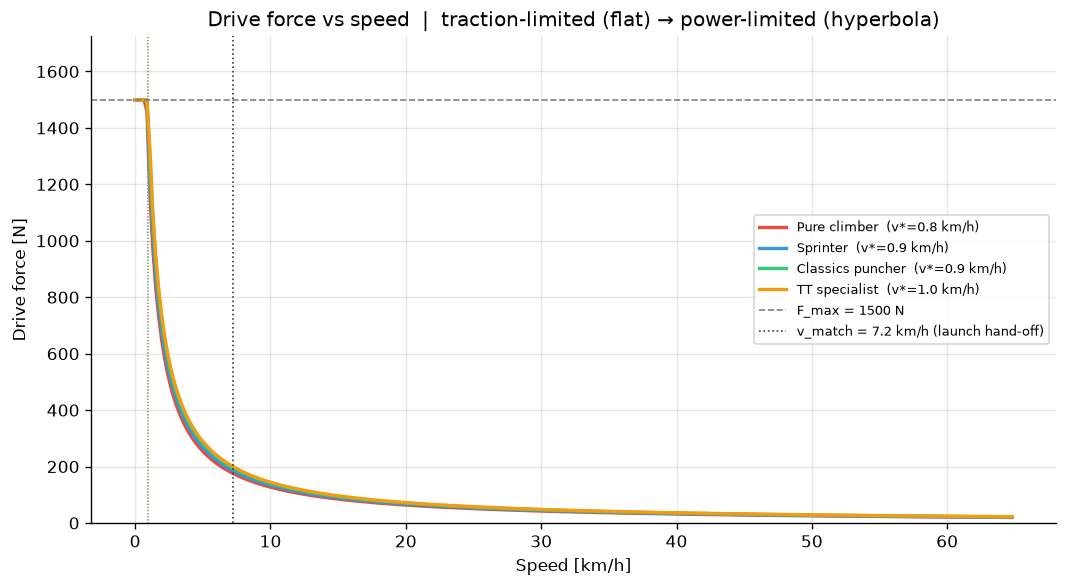

In [27]:
# F_drive(v): traction-limited → power-limited crossover
v_sweep = np.linspace(1e-3, 18, 300)

fig, ax = plt.subplots(figsize=(9, 5))
for (name, col) in zip(ARCHETYPE_NAMES, ARCH_COLORS):
    a   = ARCHETYPES[name]
    F_traction = np.full_like(v_sweep, F_MAX_N)
    F_power    = a["cp"] * (1 - L_DRIVE) / v_sweep
    F_actual   = np.minimum(F_traction, F_power)
    v_cross = a["cp"] * (1 - L_DRIVE) / F_MAX_N
    ax.plot(v_sweep * 3.6, F_actual, color=col, lw=2, label=f"{name}  (v*={v_cross*3.6:.1f} km/h)")
    ax.axvline(v_cross * 3.6, color=col, lw=0.7, ls=":", alpha=0.6)

ax.axhline(F_MAX_N, color="gray", lw=1, ls="--", label=f"F_max = {F_MAX_N:.0f} N")
ax.axvline(V_MATCH_M_PER_S * 3.6, color="#2c3e50", lw=1, ls=":",
           label=f"v_match = {V_MATCH_M_PER_S*3.6:.1f} km/h (launch hand-off)")
ax.set_xlabel("Speed [km/h]")
ax.set_ylabel("Drive force [N]")
ax.set_title("Drive force vs speed  |  traction-limited (flat) → power-limited (hyperbola)")
ax.legend(fontsize=8)
ax.set_ylim(0, F_MAX_N * 1.15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_49977/4032882493.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax_t7.set_xticklabels(names_l, rotation=15, ha="right")
/tmp/ipykernel_49977/4032882493.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax_w7.set_xticklabels(names_l, rotation=15, ha="right")


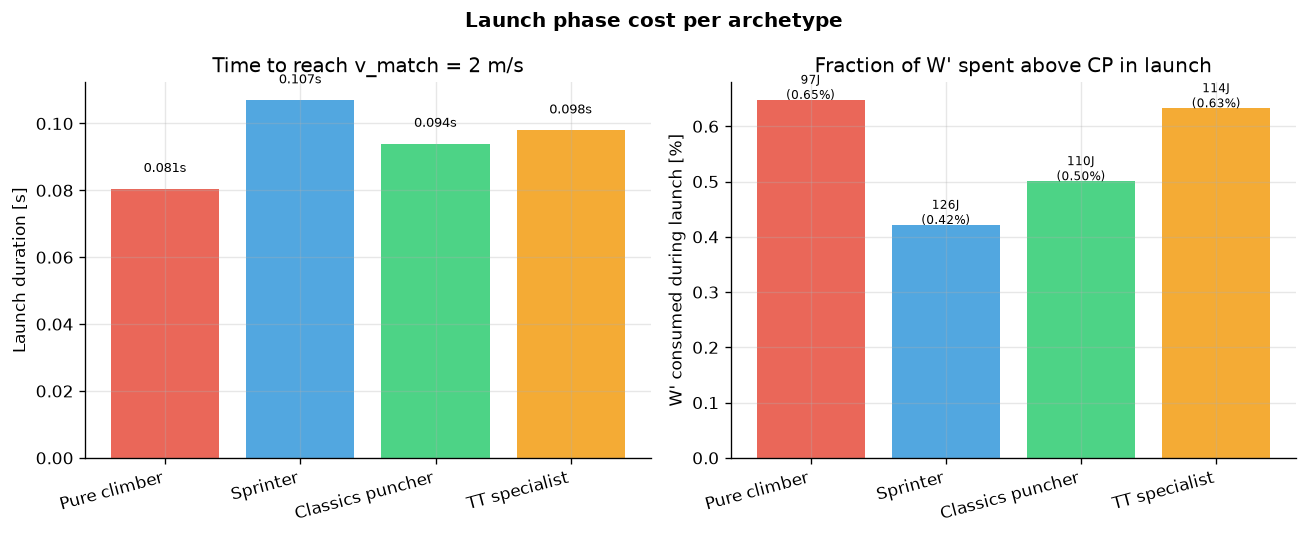

In [28]:
# W' consumed during launch phase
# Approximate: integrate P_excess = max(0, P_crank - CP) over launch time
launch_wp_costs = {}
launch_times    = {}

for name in ARCHETYPE_NAMES:
    a  = ARCHETYPES[name]
    t_, v_, F_, P_ = simulate_launch(
        a["mass"], F_MAX_N, a["crr"], a["cda"], RHO_KG_PER_M3,
        a["cp"], L_DRIVE, v_match=V_MATCH_M_PER_S)
    dt_launch = np.diff(t_)
    p_excess  = np.maximum(0, P_[:-1] - a["cp"])
    w_cost    = np.sum(p_excess * dt_launch)
    launch_wp_costs[name] = w_cost
    launch_times[name]    = t_[-1]

fig, (ax_t7, ax_w7) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("Launch phase cost per archetype", fontweight="bold")

names_l = list(launch_times.keys())
t_vals  = [launch_times[n] for n in names_l]
w_vals  = [launch_wp_costs[n] for n in names_l]
wp0_vals= [ARCHETYPES[n]["w_prime"] for n in names_l]

bars1 = ax_t7.bar(names_l, t_vals, color=ARCH_COLORS, alpha=0.85)
ax_t7.set_ylabel("Launch duration [s]")
ax_t7.set_title("Time to reach v_match = 2 m/s")
ax_t7.set_xticklabels(names_l, rotation=15, ha="right")
for bar, tv in zip(bars1, t_vals):
    ax_t7.text(bar.get_x() + bar.get_width()/2, tv + 0.005, f"{tv:.3f}s",
               ha="center", fontsize=8)

pct_vals = [w/w0*100 for w, w0 in zip(w_vals, wp0_vals)]
bars2 = ax_w7.bar(names_l, pct_vals, color=ARCH_COLORS, alpha=0.85)
ax_w7.set_ylabel("W' consumed during launch [%]")
ax_w7.set_title("Fraction of W' spent above CP in launch")
ax_w7.set_xticklabels(names_l, rotation=15, ha="right")
for bar, pv, wv in zip(bars2, pct_vals, w_vals):
    ax_w7.text(bar.get_x() + bar.get_width()/2, pv + 0.002,
               f"{wv:.0f}J\n({pv:.2f}%)", ha="center", fontsize=7)

plt.tight_layout()
plt.show()

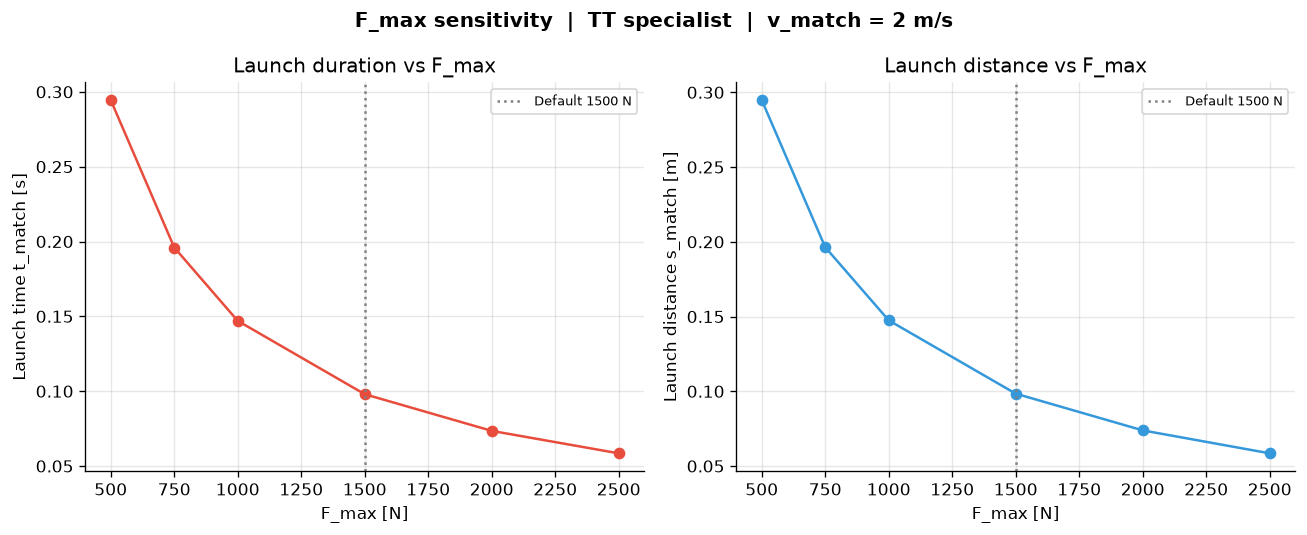

In [29]:
# F_max sensitivity — TT specialist
f_max_sweep = [500, 750, 1000, 1500, 2000, 2500]
a_tt2 = ARCHETYPES["TT specialist"]

t_match_arr, s_match_arr = [], []
for fmax in f_max_sweep:
    t_, v_, _, _ = simulate_launch(
        a_tt2["mass"], float(fmax), a_tt2["crr"], a_tt2["cda"],
        RHO_KG_PER_M3, a_tt2["cp"], L_DRIVE, v_match=V_MATCH_M_PER_S)
    dt_ = np.diff(t_)
    v_mid_ = (v_[:-1] + v_[1:]) / 2
    s_match = np.sum(v_mid_ * dt_)
    t_match_arr.append(t_[-1])
    s_match_arr.append(s_match)

fig, (ax_ft, ax_fs) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("F_max sensitivity  |  TT specialist  |  v_match = 2 m/s", fontweight="bold")

ax_ft.plot(f_max_sweep, t_match_arr, "o-", color="#e74c3c")
ax_ft.set_xlabel("F_max [N]")
ax_ft.set_ylabel("Launch time t_match [s]")
ax_ft.set_title("Launch duration vs F_max")
ax_ft.axvline(F_MAX_N, color="gray", ls=":", label=f"Default {F_MAX_N:.0f} N")
ax_ft.legend(fontsize=8)

ax_fs.plot(f_max_sweep, s_match_arr, "o-", color="#3498db")
ax_fs.set_xlabel("F_max [N]")
ax_fs.set_ylabel("Launch distance s_match [m]")
ax_fs.set_title("Launch distance vs F_max")
ax_fs.axvline(F_MAX_N, color="gray", ls=":", label=f"Default {F_MAX_N:.0f} N")
ax_fs.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## §8 — Simulation diagnostics

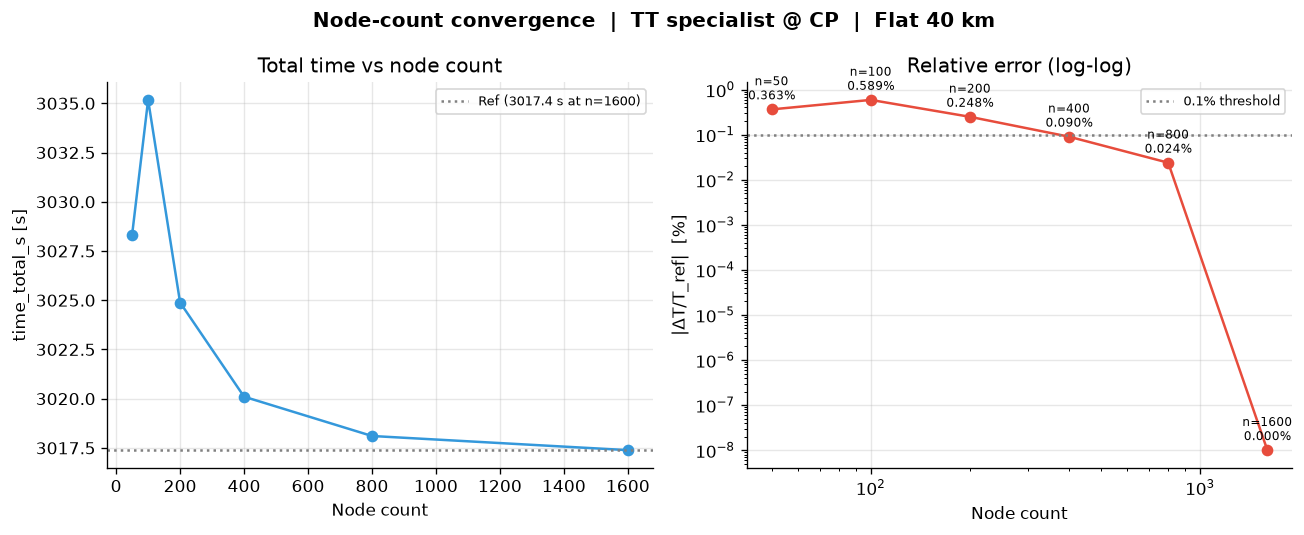

In [30]:
# Node-count convergence — flat course, TT specialist at CP
n_nodes_sweep = [50, 100, 200, 400, 800, 1600]
rider_tt = RIDERS["TT specialist"]
times_nn  = []

for nn in n_nodes_sweep:
    raw = CourseData(
        s_m=np.linspace(0, 40_000, nn),
        grade=np.full(nn, 1e-3),
        bearing_rad=np.full(nn, 1e-4),
        surface_factor=np.ones(nn),
    )
    c = CourseProcessor().process(raw, nn, smoothing_length_m=200.0)
    res = SIM.simulate(rider_tt, c, CALM_WIND, np.full(nn, float(a_tt2["cp"])))
    times_nn.append(res.time_total_s)

ref_time_nn = times_nn[-1]  # n=1600 as reference
rel_err = np.abs(np.array(times_nn) - ref_time_nn) / ref_time_nn * 100

fig, (ax_t8, ax_e8) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("Node-count convergence  |  TT specialist @ CP  |  Flat 40 km", fontweight="bold")

ax_t8.plot(n_nodes_sweep, times_nn, "o-", color="#3498db")
ax_t8.axhline(ref_time_nn, color="gray", ls=":", label=f"Ref ({ref_time_nn:.1f} s at n=1600)")
ax_t8.set_xlabel("Node count")
ax_t8.set_ylabel("time_total_s [s]")
ax_t8.set_title("Total time vs node count")
ax_t8.legend(fontsize=8)

ax_e8.loglog(n_nodes_sweep, rel_err + 1e-8, "o-", color="#e74c3c")
ax_e8.axhline(0.1, color="gray", ls=":", label="0.1% threshold")
ax_e8.set_xlabel("Node count")
ax_e8.set_ylabel("|ΔT/T_ref|  [%]")
ax_e8.set_title("Relative error (log-log)")
ax_e8.legend(fontsize=8)
for nn, re in zip(n_nodes_sweep, rel_err):
    ax_e8.annotate(f"n={nn}\n{re:.3f}%", xy=(nn, re + 1e-8), fontsize=7,
                   xytext=(0, 6), textcoords="offset points", ha="center")

plt.tight_layout()
plt.show()

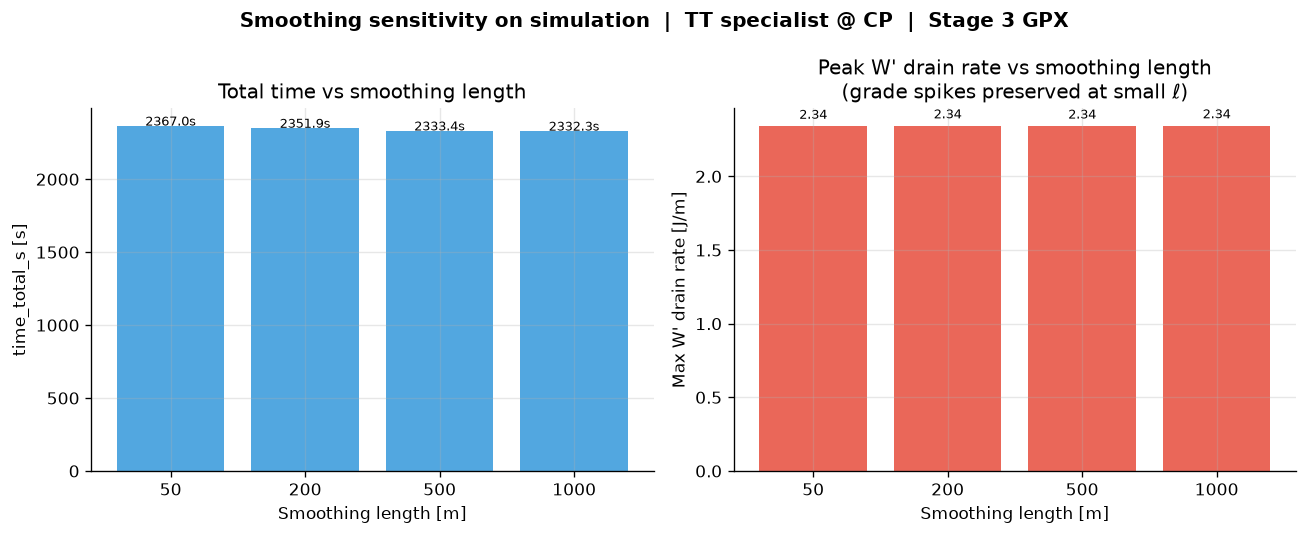

In [31]:
# Effect of smoothing_length_m on simulation output — GPX course, TT specialist at CP
cp_tt3 = ARCHETYPES["TT specialist"]["cp"]
smooth_sweep = [50, 200, 500, 1000]
sim_times_sm, max_drain_sm = [], []

for ell in smooth_sweep:
    c = CourseProcessor().process(gpx_raw, 600, smoothing_length_m=float(ell))
    res = SIM.simulate(rider_tt, c, CALM_WIND, np.full(len(c.s_m), float(cp_tt3)))
    sim_times_sm.append(res.time_total_s)
    drain = -np.diff(res.w_prime_bal_J) / np.diff(res.s_m)
    max_drain_sm.append(drain.max())

fig, (ax_ts, ax_ds) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("Smoothing sensitivity on simulation  |  TT specialist @ CP  |  Stage 3 GPX",
             fontweight="bold")

ax_ts.bar([str(e) for e in smooth_sweep], sim_times_sm, color="#3498db", alpha=0.85)
ax_ts.set_xlabel("Smoothing length [m]")
ax_ts.set_ylabel("time_total_s [s]")
ax_ts.set_title("Total time vs smoothing length")
for i, (sv, tv) in enumerate(zip(smooth_sweep, sim_times_sm)):
    ax_ts.text(i, tv + 0.5, f"{tv:.1f}s", ha="center", fontsize=8)

ax_ds.bar([str(e) for e in smooth_sweep], max_drain_sm, color="#e74c3c", alpha=0.85)
ax_ds.set_xlabel("Smoothing length [m]")
ax_ds.set_ylabel("Max W' drain rate [J/m]")
ax_ds.set_title("Peak W' drain rate vs smoothing length\n(grade spikes preserved at small ℓ)")
for i, (sv, dv) in enumerate(zip(smooth_sweep, max_drain_sm)):
    ax_ds.text(i, dv + 0.05, f"{dv:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()